In [1]:
"""
Unified EOS Analysis Tool.
1. plot_eos_curves(*args) -> Plots spaghetti curves.
2. compare_eos_results(*args) -> Plots histograms.

Args can be:
- "path/to/file.h5" (No filter)
- ("path/to/file.h5", {'param': (min, max)}) (With filter)
"""

import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
os.environ["JAX_PLATFORMS"] = "cpu"
import logging
from matplotlib.collections import LineCollection
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import jax
print(jax.devices())  # Output: [CpuDevice(id=0)]
# --- JesterTOV Imports ---
jax.config.update("jax_platforms", "cpu")
try:
    from jesterTOV import utils
except ImportError:
    class utils:
        fm_inv3_to_SI = 1e45 
        geometric_to_MeV_fm_inv3 = 1.0

# ==============================================================================
#                               MASTER CONFIGURATION
# ==============================================================================

logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger("eos_master")

PLOT_CONFIG = {
    "DPI": 150, "USE_TEX": True, "FIG_SIZE": (14, 6),
    "NUM_SAMPLES": 500, "ALPHA": 0.15, "LINEWIDTH": 1.0,
    "FIG_WIDTH": 16, "COLS": 4, "BINS": 40
}

try:
    CURRENT_DIR = Path(__file__).resolve().parent
except NameError:
    CURRENT_DIR = Path.cwd()

ROOT_JESTER = CURRENT_DIR.parents[1] 
BASE_PATH = ROOT_JESTER / "jesterTOV" / "inference"

CHIEFT_CONFIG = {
    "DATA_DIR": BASE_PATH / "data" / "chiEFT" / "2402.04172",
    "LOW_FILE": "low.dat", "HIGH_FILE": "high.dat",
    "COLOR": "gray", "ALPHA": 0.7, "ZORDER": 0,
}

N_SAT_FM = 0.16 
N_SAT_SI = N_SAT_FM * utils.fm_inv3_to_SI
GEOM_TO_MEVFM3 = utils.geometric_to_MeV_fm_inv3

def setup_matplotlib():
    plt.rcParams.update({
        "axes.grid": True, "grid.alpha": 0.3, "axes.labelsize": 14,
        "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
        "figure.titlesize": 16, "mathtext.fontset": "cm", "font.family": "serif"
    })
    if PLOT_CONFIG["USE_TEX"]:
        try:
            from matplotlib.checkdep_usetex import checkdep_usetex
            if checkdep_usetex(True):
                plt.rcParams.update({"text.usetex": True})
        except: pass

# ==============================================================================
#                                DATA LOADING
# ==============================================================================

def load_h5_data(filepath, mode="curves", filters=None):
    """
    Robust loader that handles ragged arrays and filtering.
    """
    if not os.path.exists(filepath):
        logger.warning(f"⚠️ File not found: {filepath}")
        return None

    with h5py.File(filepath, 'r') as f:
        if 'posterior' not in f: return None
        post = f['posterior']
        
        # --- 1. DETERMINE REFERENCE LENGTH ---
        n_samples = 0
        ref_param = None
        
        # If filtering, the filter param dictates the length
        if filters and 'parameters' in post:
            for k in filters.keys():
                if k in post['parameters']:
                    n_samples = post['parameters'][k].shape[0]
                    ref_param = k
                    break
        
        # Fallback length detection
        if n_samples == 0:
            if 'parameters' in post:
                ref_param = list(post['parameters'].keys())[0]
                n_samples = post['parameters'][ref_param].shape[0]
            elif 'derived_eos' in post:
                grp = post['derived_eos']
                k = 'masses_EOS' if 'masses_EOS' in grp else 'masses'
                n_samples = grp[k].shape[0]

        if n_samples == 0:
            return None

        # --- 2. GENERATE MASK ---
        mask = np.ones(n_samples, dtype=bool)

        if filters and 'parameters' in post:
            for param, bounds in filters.items():
                if param in post['parameters']:
                    dset = post['parameters'][param]
                    # SAFETY: Check length before masking
                    if dset.shape[0] != n_samples:
                        logger.warning(f"   ⚠️ Skipping filter '{param}': length mismatch.")
                        continue
                    
                    data_vec = dset[:]
                    mask = mask & ((data_vec >= bounds[0]) & (data_vec <= bounds[1]))
                    logger.info(f"   Refining [{os.path.basename(filepath)}] filter '{param}': kept {np.sum(mask)}/{n_samples}")

        if np.sum(mask) == 0:
            logger.warning(f"   ❌ All data filtered out for {os.path.basename(filepath)}")
            return None

        # --- MODE: CURVES ---
        if mode == "curves":
            group = post.get('derived_eos', post)
            if 'masses' not in group and 'masses_EOS' not in group: return None
            try:
                m = group.get('masses_EOS', group.get('masses'))[:]
                r = group.get('radii_EOS', group.get('radii'))[:]
                n = group.get('n')[:] / N_SAT_SI
                p = group.get('p')[:] * GEOM_TO_MEVFM3
                
                # Align with n_samples
                if len(m) > n_samples:
                    m, r, n, p = m[:n_samples], r[:n_samples], n[:n_samples], p[:n_samples]
                elif len(m) < n_samples:
                    return None # Cannot safely mask

                final_m, final_r, final_n, final_p = [], [], [], []
                indices = np.where(mask)[0]
                for i in indices:
                    if len(m[i]) > 1:
                        final_m.append(m[i])
                        final_r.append(r[i])
                        final_n.append(n[i])
                        final_p.append(p[i])

                if not final_m: return None
                return {'m': final_m, 'r': final_r, 'n': final_n, 'p': final_p}
            except Exception as e:
                logger.error(f"Failed to read curves: {e}")
                return None

        # --- MODE: PARAMS ---
        elif mode == "params":
            data = {}
            if 'parameters' in post:
                for k in post['parameters'].keys():
                    dset = post['parameters'][k]
                    if dset.shape[0] == n_samples:
                        data[k] = dset[:][mask]
            
            eos_group = post.get('derived_eos', post)
            
            def add_derived(name, arr):
                if len(arr) >= n_samples:
                    data[name] = arr[:n_samples][mask]

            if 'M_TOV' not in data:
                try:
                    masses = eos_group.get('masses_EOS', eos_group.get('masses'))[:]
                    if len(masses) >= n_samples:
                        m_tov = np.array([np.max(m) if len(m) > 0 else 0 for m in masses])
                        add_derived('M_TOV', m_tov)
                except: pass
            
            if 'R_1.4' not in data:
                try:
                    masses = eos_group.get('masses_EOS', eos_group.get('masses'))[:]
                    radii = eos_group.get('radii_EOS', eos_group.get('radii'))[:]
                    if len(masses) >= n_samples:
                        r14 = []
                        for i in range(len(masses)):
                            m, r = masses[i], radii[i]
                            if len(m) > 1:
                                srt = np.argsort(m)
                                r14.append(np.interp(1.4, m[srt], r[srt]))
                            else:
                                r14.append(np.nan)
                        add_derived('R_1.4', np.array(r14))
                except: pass
            return data
    return None

def get_segments(x_data, y_data, n_samples):
    """Helper for LineCollection."""
    total = len(x_data)
    if total == 0: return []
    N = min(total, n_samples)
    indices = np.random.choice(total, N, replace=False)
    segments = []
    for i in indices:
        x, y = x_data[i], y_data[i]
        mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
        if np.sum(mask) > 1:
            segments.append(np.column_stack([x[mask], y[mask]]))
    return segments

def get_fancy_label(name):
    MAPPING = {
        'M_TOV': r'$M_{\rm{TOV}}$ $[M_{\odot}]$', 'R_1.4': r'$R_{1.4}$ [km]',
        'P_3nsat': r'$P(3n_{\rm{sat}})$ [MeV fm$^{-3}$]', 'L_sym': r'$L_{\rm{sym}}$',
        'K_sat': r'$K_{\rm{sat}}$', 'chi2': r'$\chi^2$', 'log_prob': r'$\ln \mathcal{L}$'
    }
    if name in MAPPING: return MAPPING[name]
    parts = name.split('_')
    base = parts[0]
    if base in ['alpha', 'beta', 'gamma', 'delta', 'rho', 'sigma', 'kappa', 'lambda', 'epsilon']:
        base = f"\\{base}"
    if len(parts) > 1: return f"${base}_{{{r'\_'.join(parts[1:])}}}$"
    return f"${base}$"

# ==============================================================================
#                               PLOT FUNCTION 1: CURVES
# ==============================================================================

def plot_eos_curves(*args, labels=None):
    """
    Plots EOS/MR curves.
    Input: "file.h5" OR ("file.h5", filter_dict)
    """
    setup_matplotlib()
    datasets, valid_paths = [], []
    
    logger.info(f"⏳ [Curves] Processing {len(args)} inputs...")
    
    for item in args:
        # Parse Input: Tuple or String?
        if isinstance(item, (tuple, list)) and len(item) == 2:
            fpath, f_dict = item
        else:
            fpath, f_dict = item, None
            
        d = load_h5_data(fpath, mode="curves", filters=f_dict)
        if d:
            datasets.append(d)
            valid_paths.append(fpath)
            
    if not datasets: 
        logger.error("No data found or all filtered out.")
        return

    if not labels: labels = [os.path.basename(p) for p in valid_paths]
    if len(labels) < len(datasets): labels += [os.path.basename(p) for p in valid_paths[len(labels):]]
        
    colors = plt.cm.tab10(np.linspace(0, 1, 10)) if len(datasets) <= 10 else plt.cm.turbo(np.linspace(0, 1, len(datasets)))

    fig, (ax_eos, ax_mr) = plt.subplots(1, 2, figsize=PLOT_CONFIG["FIG_SIZE"], dpi=PLOT_CONFIG["DPI"])
    
    # Background: ChiEFT
    try:
        low_path = CHIEFT_CONFIG["DATA_DIR"] / CHIEFT_CONFIG["LOW_FILE"]
        high_path = CHIEFT_CONFIG["DATA_DIR"] / CHIEFT_CONFIG["HIGH_FILE"]
        if low_path.exists() and high_path.exists():
            low = np.loadtxt(low_path)
            high = np.loadtxt(high_path)
            min_len = min(len(low), len(high))
            ax_eos.fill_between(low[:min_len, 0]/N_SAT_FM, low[:min_len, 1], high[:min_len, 1],
                                color=CHIEFT_CONFIG["COLOR"], alpha=CHIEFT_CONFIG["ALPHA"], zorder=0, label="ChiEFT")
    except: pass

    # Foreground
    for i, data in enumerate(datasets):
        c, lbl = colors[i], labels[i]
        
        segs = get_segments(data['n'], data['p'], PLOT_CONFIG["NUM_SAMPLES"])
        if segs:
            ax_eos.add_collection(LineCollection(segs, colors=c, alpha=PLOT_CONFIG["ALPHA"], linewidths=PLOT_CONFIG["LINEWIDTH"]))
            ax_eos.plot([], [], color=c, label=lbl, lw=2)

        segs_mr = get_segments(data['r'], data['m'], PLOT_CONFIG["NUM_SAMPLES"])
        if segs_mr:
            ax_mr.add_collection(LineCollection(segs_mr, colors=c, alpha=PLOT_CONFIG["ALPHA"], linewidths=PLOT_CONFIG["LINEWIDTH"]))

    ax_eos.set_xscale('log'); ax_eos.set_yscale('log')
    ax_eos.set_xlim(3e-1, 2.5); ax_eos.set_ylim(1e-1, 30)
    ax_eos.set_xlabel(r"$n/n_{\rm{sat}}$"); ax_eos.set_ylabel(r"$P$ [MeV fm$^{-3}$]")
    ax_eos.legend(loc='upper left')
    
    ax_mr.set_xlim(8, 18); ax_mr.set_ylim(0.5, 3.0)
    ax_mr.set_xlabel(r"$R$ [km]"); ax_mr.set_ylabel(r"$M$ $[M_{\odot}]$")
    plt.tight_layout()
    plt.show()

# ==============================================================================
#                               PLOT FUNCTION 2: HISTOGRAMS
# ==============================================================================

def compare_eos_results(*args, labels=None):
    """
    Plots histograms.
    Input: "file.h5" OR ("file.h5", filter_dict)
    """
    setup_matplotlib()
    datasets, valid_paths = [], []
    
    logger.info(f"⏳ [Histograms] Processing {len(args)} inputs...")
    
    for item in args:
        # Parse Input: Tuple or String?
        if isinstance(item, (tuple, list)) and len(item) == 2:
            fpath, f_dict = item
        else:
            fpath, f_dict = item, None

        d = load_h5_data(fpath, mode="params", filters=f_dict)
        if d:
            datasets.append(d)
            valid_paths.append(fpath)

    if not datasets:
        logger.error("No data found or all filtered out.")
        return

    if not labels: labels = [os.path.basename(p) for p in valid_paths]
    if len(labels) < len(datasets): labels += [os.path.basename(p) for p in valid_paths[len(labels):]]

    colors = plt.cm.tab10(np.linspace(0, 1, 10)) if len(datasets) <= 10 else plt.cm.turbo(np.linspace(0, 1, len(datasets)))

    all_keys = sorted(list(set().union(*(d.keys() for d in datasets))))
    valid_keys = [k for k in all_keys if any(k in d and d[k].ndim==1 and np.std(d[k])>1e-12 for d in datasets)]

    if not valid_keys: return

    n_plots = len(valid_keys)
    cols = PLOT_CONFIG["COLS"]
    rows = (n_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(PLOT_CONFIG["FIG_WIDTH"], rows * 3.5), dpi=PLOT_CONFIG["DPI"])
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, param in enumerate(valid_keys):
        ax = axes[i]
        for j, data in enumerate(datasets):
            if param in data:
                d = data[param][np.isfinite(data[param])]
                if len(d) == 0: continue
                
                lbl = labels[j] if i == 0 else ""
                ax.hist(d, bins=PLOT_CONFIG["BINS"], density=True, color=colors[j], alpha=0.3, label=lbl)
                ax.hist(d, bins=PLOT_CONFIG["BINS"], density=True, color=colors[j], histtype='step', linewidth=1.5)
                ax.axvline(np.median(d), color=colors[j], linestyle='--', alpha=0.8)
        
        ax.set_title(get_fancy_label(param))
        ax.set_yticks([]); ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    for j in range(i+1, len(axes)): axes[j].axis('off')
    fig.legend(loc='upper center', ncol=min(len(datasets), 5), frameon=False, bbox_to_anchor=(0.5, 1.01))
    plt.tight_layout()
    plt.show()

[CpuDevice(id=0)]


⏳ [Curves] Processing 1 inputs...


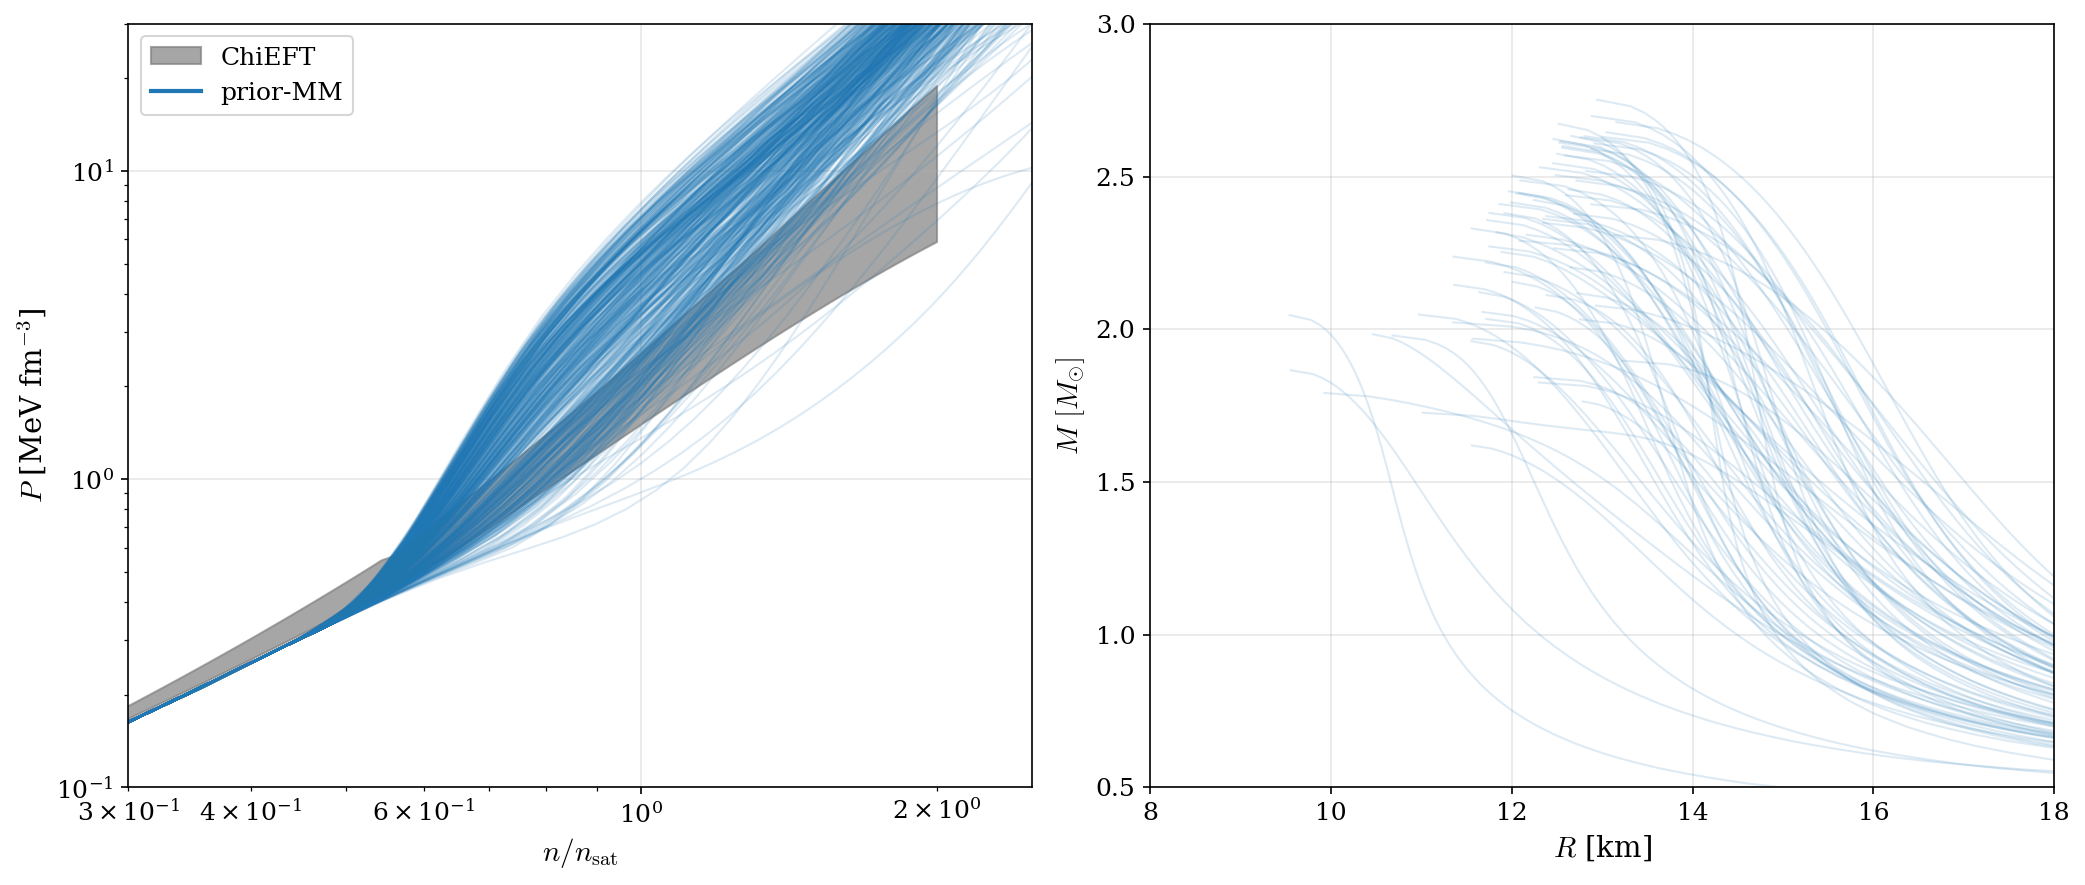

In [2]:

files_to_compare = [
    "smc_random_walk/prior/outdir/results.h5",
#     "skyrme_smc_random_walk/prior/outdir/results.h5",
#     "skyrme_smc_random_walk/chiEFT-flow/outdir/results.h5",
]

my_labels = [
    "prior-MM", #"prior-Skyrme-large_nbreak","chiEFT-Skyrme-large_nbreak"
]

plot_eos_curves(*files_to_compare, labels=my_labels)


⏳ [Histograms] Processing 2 inputs...


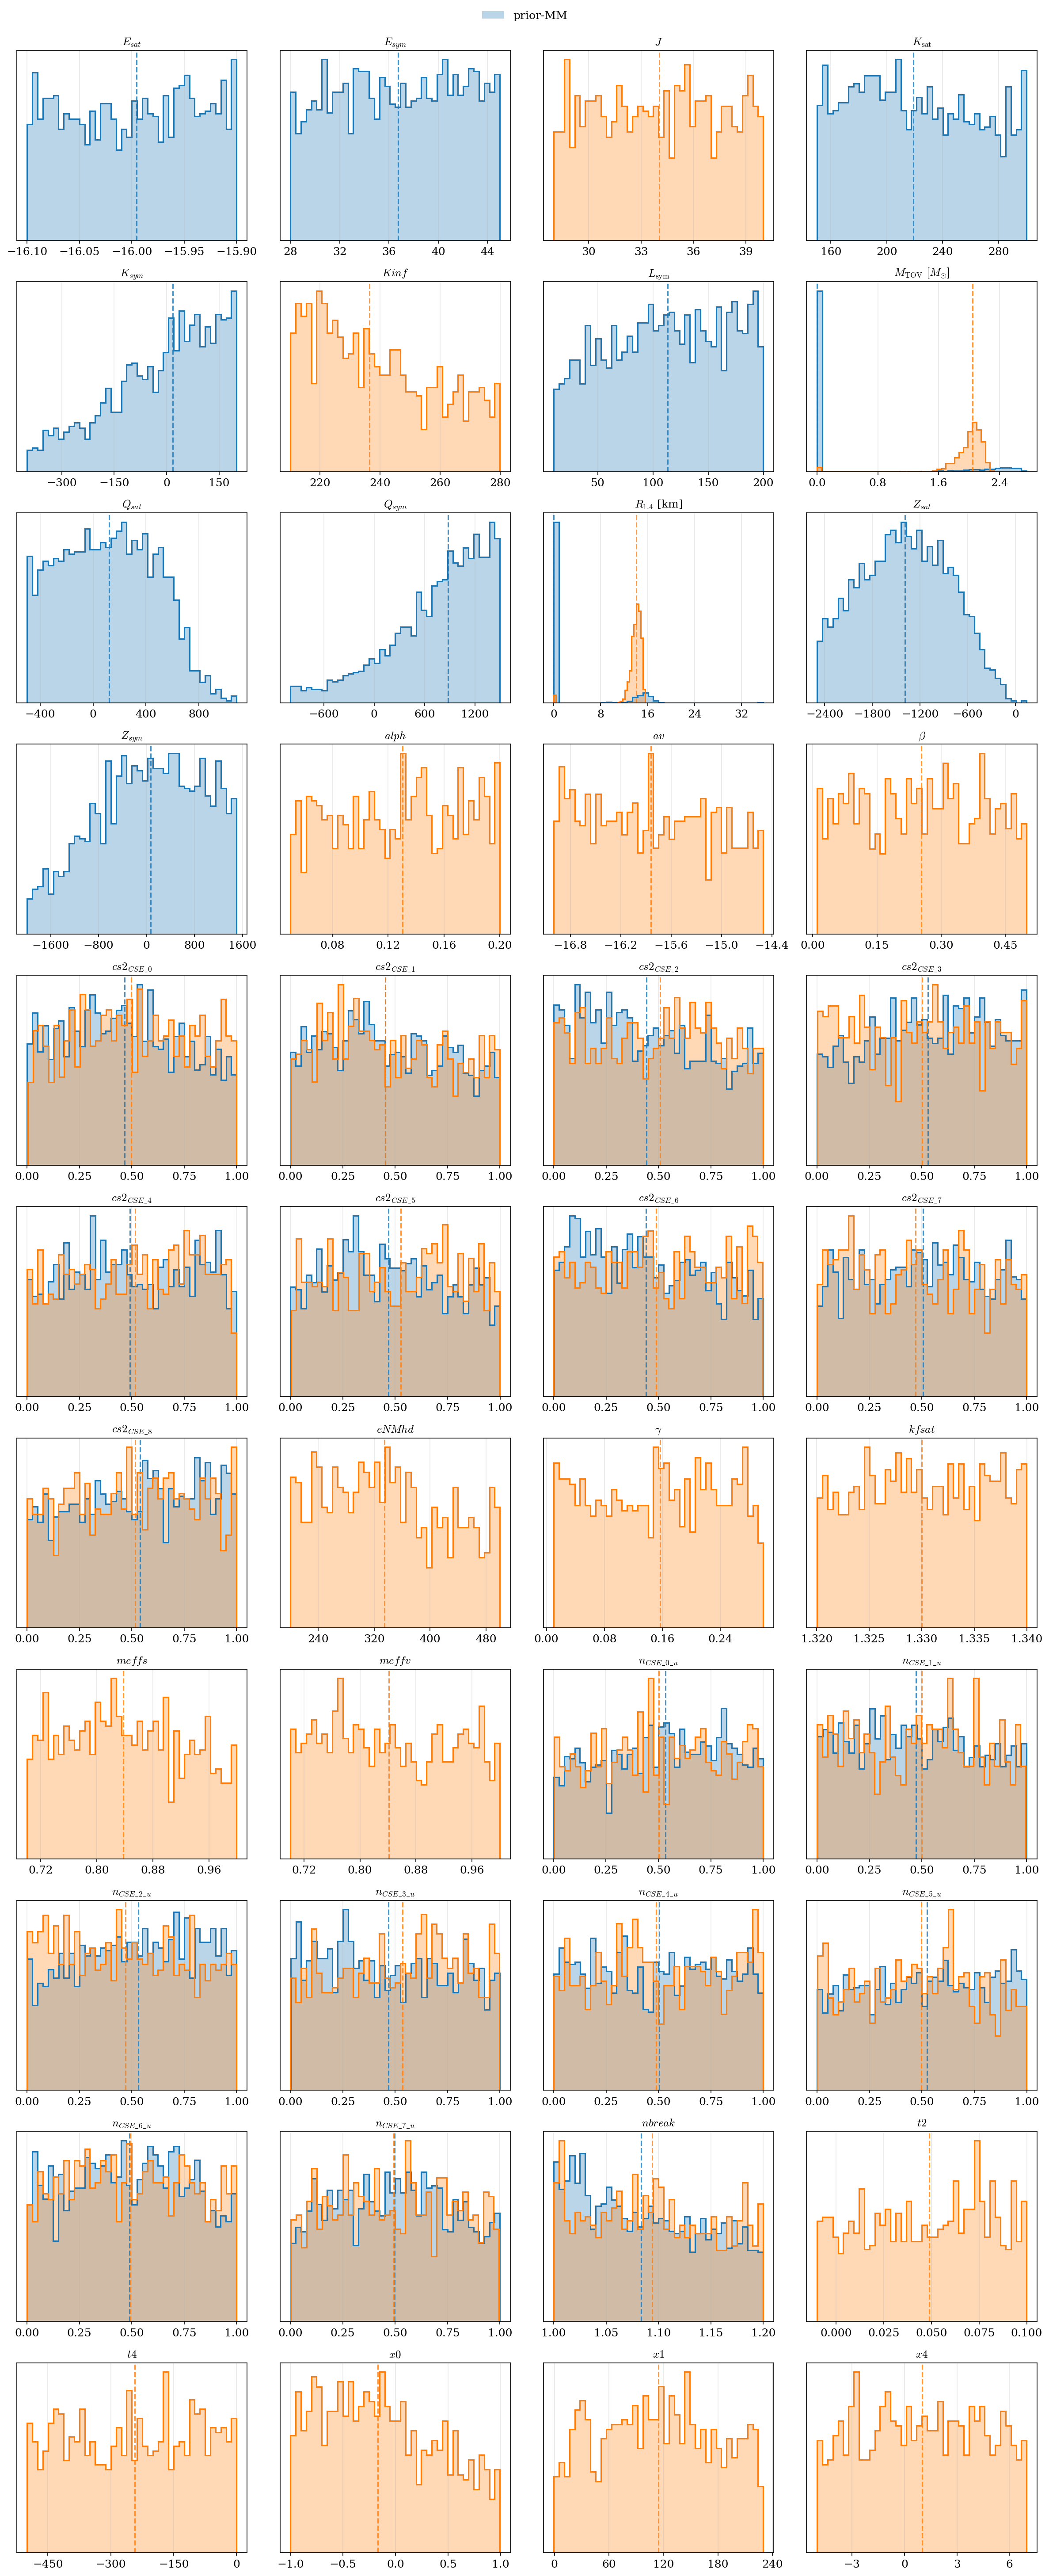

⏳ [Curves] Processing 2 inputs...


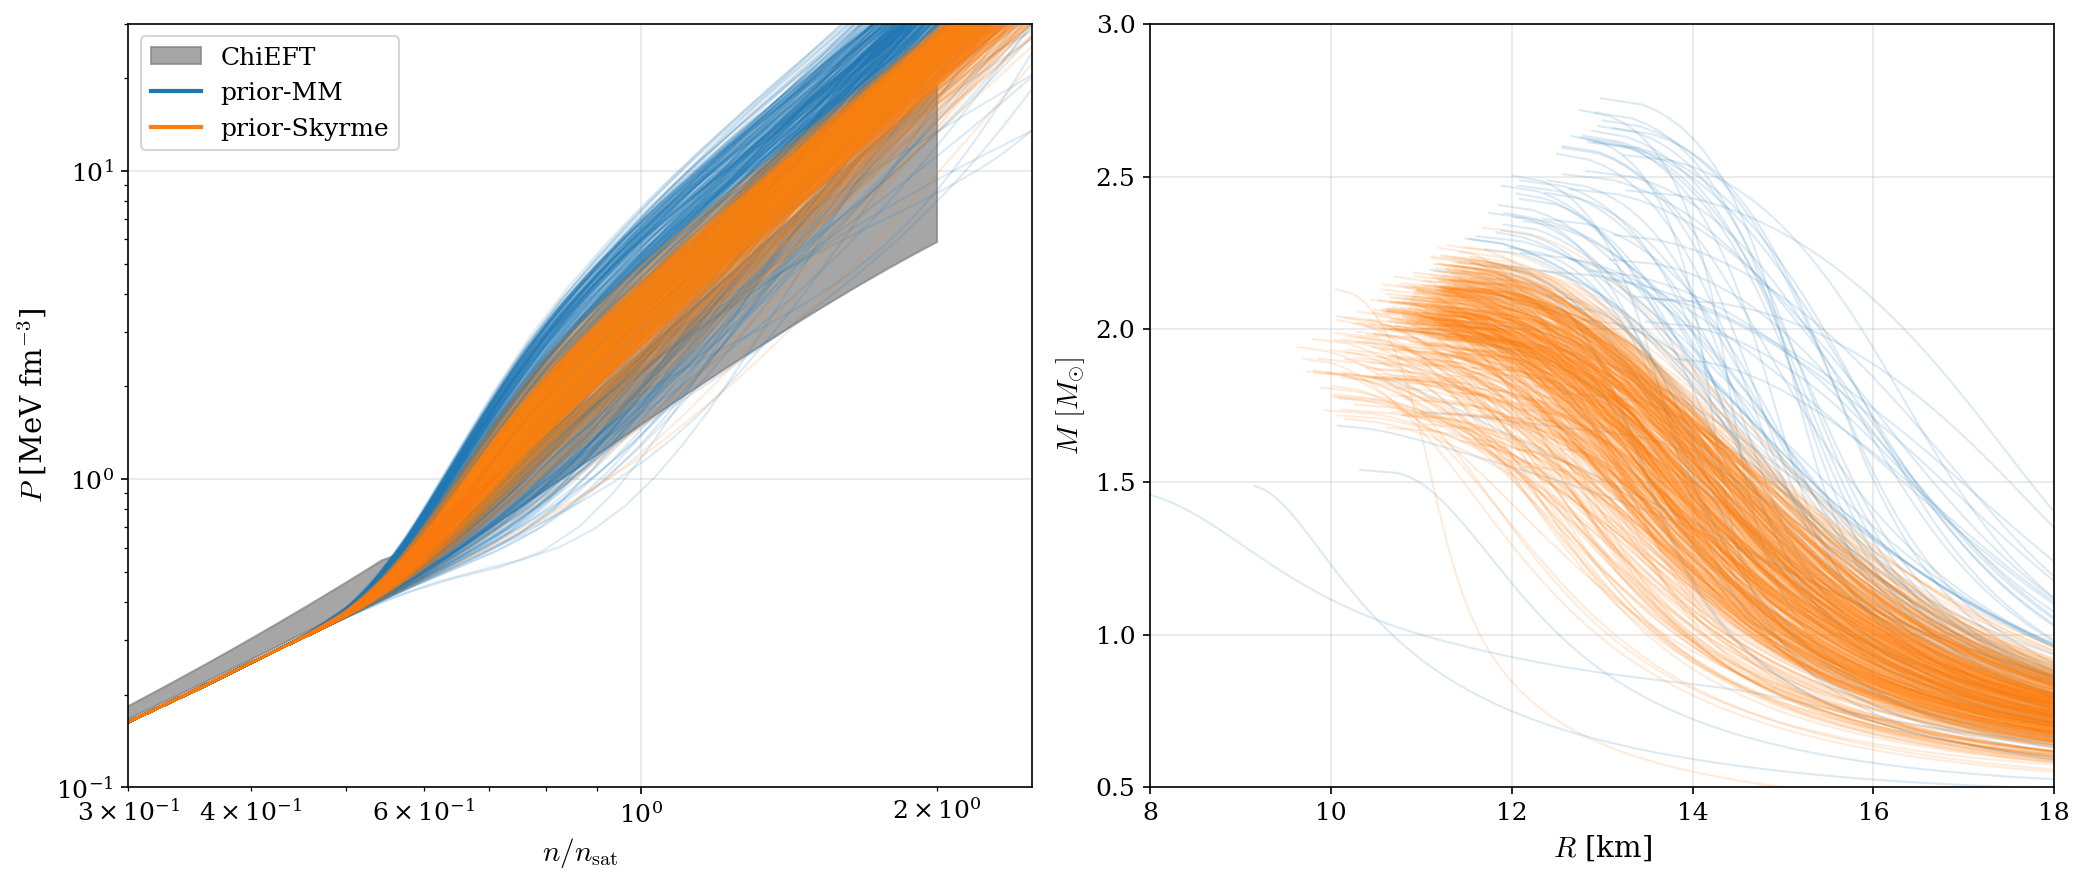

In [3]:
files_to_compare = [
    "smc_random_walk/prior/outdir/results.h5",
    "skyrme_smc_random_walk/prior/outdir/results.h5",
]

my_labels = [
    "prior-MM", "prior-Skyrme"
]

# File 1: No filter
# File 2: Filter kappa < 1e7
# File 3: Filter chi2 < 5
# compare_eos_results(
#     "file1.h5", 
#     ("file2.h5", {'kappa': (0, 1e7)}),
#     ("file3.h5", {'chi2': (0, 5)}),
#     labels=["Baseline", "Low Kappa", "Good Fit"]
# )

compare_eos_results(*files_to_compare, labels=my_labels)
plot_eos_curves(*files_to_compare, labels=my_labels)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import h5py
import os
import logging
import corner
from matplotlib.ticker import MaxNLocator

# ==============================================================================
#                               CONFIG & SETUP
# ==============================================================================

logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger("corner_maker")

PARAMS_CONFIG = {
    "USE_TEX": True
}

def get_fancy_label(name):
    """Parses parameter names into LaTeX labels."""
    if not PARAMS_CONFIG["USE_TEX"]: return name
    
    MAPPING = {
        'M_TOV': r'$M_{\rm{TOV}}$ $[M_{\odot}]$', 
        'R_1.4': r'$R_{1.4}$ [km]',
        'P_3nsat': r'$P(3n_{\rm{sat}})$ [MeV fm$^{-3}$]', 
        'L_sym': r'$L_{\rm{sym}}$',
        'K_sat': r'$K_{\rm{sat}}$',
        'J_sym': r'$J_{\rm{sym}}$',
        'chi2': r'$\chi^2$', 
        'log_prob': r'$\ln \mathcal{L}$'
    }
    if name in MAPPING: return MAPPING[name]

    if "lambda" in name.lower() and "tilde" in name.lower():
        return r"$\tilde{\Lambda}$"
    
    parts = name.split('_')
    base = parts[0]
    greek_letters = ['alpha', 'beta', 'gamma', 'delta', 'rho', 'sigma', 
                     'kappa', 'lambda', 'epsilon', 'zeta', 'theta']
    if base in greek_letters:
        base = f"\\{base}"
    
    if len(parts) > 1:
        sub = r'\_'.join(parts[1:])
        return f"${base}_{{{sub}}}$"
    
    return f"${base}$"

# ==============================================================================
#                                DATA LOADING
# ==============================================================================

def load_posterior_samples(filepath, requested_params=None):
    if not os.path.exists(filepath):
        logger.warning(f"⚠️ File not found: {filepath}")
        return None, []

    data = {}
    with h5py.File(filepath, 'r') as f:
        if 'posterior' not in f: return None, []
        post = f['posterior']
        
        # Priority mapping for sourcing data
        sources = [post.get('parameters', {}), post.get('derived_eos', post)]
        
        # 1. Load basic parameters
        all_keys_in_file = set()
        for src in sources:
            if hasattr(src, "keys"): all_keys_in_file.update(src.keys())
        
        keys_to_scan = requested_params if requested_params else all_keys_in_file
        
        for k in keys_to_scan:
            for src in sources:
                if hasattr(src, "keys") and k in src:
                    val = src[k][:]
                    if val.ndim == 1:
                        data[k] = val
                        break

        # 2. Derived Physics Logic (The "Feynman Step": Calculate what's missing)
        # Kita perlu masses dan radii buat M_TOV dan R_1.4
        eos_group = post.get('derived_eos', post)
        masses = None
        radii = None
        
        try:
            masses = eos_group.get('masses_EOS', eos_group.get('masses'))[:]
            radii = eos_group.get('radii_EOS', eos_group.get('radii'))[:]
        except:
            pass

        if masses is not None:
            # Derived: M_TOV
            if 'M_TOV' in keys_to_scan and 'M_TOV' not in data:
                data['M_TOV'] = np.max(masses, axis=1)
                logger.info("  -> Derived M_TOV from mass sequences.")

            # Derived: R_1.4 (Linear Interpolation)
            if 'R_1.4' in keys_to_scan and 'R_1.4' not in data and radii is not None:
                r14_list = []
                for m, r in zip(masses, radii):
                    # Sortir dulu biar np.interp nggak ngaco
                    idx = np.argsort(m)
                    m_s, r_s = m[idx], r[idx]
                    # Pastikan 1.4 Mo ada di dalam range
                    if m_s.min() <= 1.4 <= m_s.max():
                        r14_list.append(np.interp(1.4, m_s, r_s))
                    else:
                        r14_list.append(np.nan)
                data['R_1.4'] = np.array(r14_list)
                logger.info("  -> Derived R_1.4 via interpolation.")

    # Cleanup: Remove NaNs/Infs that could break corner plots
    final_keys = []
    if data:
        # Gunakan mask dari semua kolom buat mastiin barisnya konsisten
        valid_mask = np.ones(len(next(iter(data.values()))), dtype=bool)
        for k in data:
            valid_mask &= np.isfinite(data[k])
        
        for k in list(data.keys()):
            data[k] = data[k][valid_mask]
            final_keys.append(k)
            
    return data, final_keys

# ==============================================================================
#                                CORNER FUNCTION
# ==============================================================================

def make_comparison_corner(*file_paths, params=None, labels=None, limits=None, outdir=".", filename="corner_comparison.pdf"):
    # 1. Setup Labels & Colors
    valid_paths = [p for p in file_paths if os.path.exists(p)]
    if not valid_paths: logger.error("💀 No valid files found."); return

    if labels is None: labels = [os.path.basename(p) for p in valid_paths]
    
    n_files = len(valid_paths)
    colors = plt.cm.tab10(np.linspace(0, 1, 10)) if n_files <= 10 else plt.cm.turbo(np.linspace(0, 1, n_files))

    # 2. Load Data
    loaded_datasets = []
    common_keys = None
    for fp in valid_paths:
        d, keys = load_posterior_samples(fp, requested_params=params)
        if d:
            loaded_datasets.append(d)
            if common_keys is None: common_keys = set(keys)
            else: common_keys.intersection_update(keys)

    if not loaded_datasets: logger.error("❌ No data loaded."); return

    plot_keys = params if params else sorted(list(common_keys))

    # 3. Global Ranges (X-Axis)
    global_ranges = []
    for k in plot_keys:
        if limits and k in limits:
            global_ranges.append(limits[k])
        else:
            combined_data = np.concatenate([d[k] for d in loaded_datasets])
            global_ranges.append((np.min(combined_data), np.max(combined_data)))

    logger.info(f"🎨 Plotting corner for: {plot_keys}")
    
    # 4. Plotting Loop
    fig = None
    fancy_labels = [get_fancy_label(k) for k in plot_keys]

    for i, data in enumerate(loaded_datasets):
        samples = np.column_stack([data[k] for k in plot_keys])
        
        # Normalisasi Manual (Weights)
        my_weights = np.ones(len(samples)) / len(samples)
        
        # Styling
        hist_settings = {"linewidth": 2} # Density HARUS False/None disini, diurus weights

        if fig is None:
            fig = corner.corner(
                samples,
                labels=fancy_labels,
                color=colors[i],
                weights=my_weights,
                range=global_ranges,
                smooth=0.9, # Sedikit smoothing biar ga bergerigi banget
                quantiles=[0.16, 0.5, 0.84],
                show_titles=True,
                plot_datapoints=False,
                plot_density=False,
                fill_contours=True,
                levels=(0.68, 0.95),
                hist_kwargs=hist_settings
            )
        else:
            corner.corner(
                samples,
                fig=fig,
                color=colors[i],
                weights=my_weights,
                range=global_ranges, # Wajib sama!
                smooth=0.9,
                plot_datapoints=False,
                plot_density=False,
                fill_contours=True,
                levels=(0.68, 0.95),
                hist_kwargs=hist_settings
            )

    # ---------------------------------------------------------
    # 5. FIX Y-AXIS CLIPPING (Rescaling Diagonal Plots)
    # ---------------------------------------------------------
    ndim = len(plot_keys)
    # Reshape flat axes list to matrix
    axes_grid = np.array(fig.axes).reshape((ndim, ndim))

    for i in range(ndim):
        ax = axes_grid[i, i] # Ambil subplot diagonal
        
        # Loop semua garis di subplot ini (histogram dari tiap dataset)
        max_heights = []
        for line in ax.lines:
            y_vals = line.get_ydata()
            if len(y_vals) > 0:
                max_heights.append(np.max(y_vals))
        
        if max_heights:
            # Cari puncak tertinggi dari semua dataset
            overall_max = np.max(max_heights)
            # Set limit baru + 10% padding
            ax.set_ylim(0, overall_max * 1.1)

    # 6. Legend
    legend_handles = []
    for i, lbl in enumerate(labels[:len(loaded_datasets)]):
        line = mlines.Line2D([], [], color=colors[i], label=lbl, linewidth=3)
        legend_handles.append(line)
    
    fig.legend(
        handles=legend_handles, 
        loc='upper left', 
        bbox_to_anchor=(0.70, 0.98), # Geser dikit biar pas
        fontsize=12, 
        frameon=False
    )

    # 7. Save
    if not os.path.exists(outdir): os.makedirs(outdir)
    save_path = os.path.join(outdir, filename)
    fig.savefig(save_path, bbox_inches="tight")
    logger.info(f"✅ Corner plot saved to: {save_path}")

# ==============================================================================
#                                   USAGE
# ==============================================================================

if __name__ == "__main__":
    
    file2 = "st_smc_random_walk/prior/outdir/results.h5"
    file1 = "st_smc_random_walk/chiEFT_radio_NICER/outdir/results.h5"


    # Define custom limits for physics parameters
    my_limits = {
        "M_TOV": (1.6, 3.5),    # Zoom in on mass
        "R_1.4": (5.0, 24),  # Zoom in on radius
        "beta_ST": (-6, 0)     # Uncomment to limit L_sym
    }

    make_comparison_corner(
        file1, #file2, 
        params=["M_TOV", "R_1.4", "beta_ST", "E_sat", "E_sym", "L_sym", "K_sat", "K_sym","cs2_CSE_0"], 
        labels=[ "chiEFT_radio_NICER", "prior"],
        limits=my_limits,  # <--- Pass limits here
        # filename="corner_physics_zoomed.pdf"
    )

arviz_base not installed
arviz_stats not installed
arviz_plots not installed
💀 No valid files found.


In [5]:
import h5py

def print_structure(name, obj):
    """
    Callback function to print the hierarchy of the HDF5 file.
    """
    # Create indentation based on depth
    depth = name.count('/')
    indent = "  " * depth
    
    if isinstance(obj, h5py.Group):
        print(f"{indent}📂 {name}/")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}📄 {name}  {obj.shape}  ({obj.dtype})")


FILENAME = "skyrme_smc_random_walk/chiEFT/outdir/results.h5"

print(f"--- Structure of {FILENAME} ---")
with h5py.File(FILENAME, 'r') as f:
    f.visititems(print_structure)


FILENAME = "smc_random_walk/chiEFT/outdir/results.h5"

print(f"--- Structure of {FILENAME} ---")
with h5py.File(FILENAME, 'r') as f:
    f.visititems(print_structure)

--- Structure of skyrme_smc_random_walk/chiEFT/outdir/results.h5 ---
📂 histories/
  📄 histories/acceptance_history  (29,)  (float64)
  📄 histories/ess_history  (29,)  (float64)
  📄 histories/tempering_param_history  (29,)  (float64)
📂 metadata/
  📄 metadata/config  ()  (object)
📂 posterior/
  📂 posterior/derived_eos/
    📄 posterior/derived_eos/Lambdas_EOS  (1000, 100)  (float64)
    📄 posterior/derived_eos/cs2  (1000, 200)  (float64)
    📄 posterior/derived_eos/dloge_dlogp  (1000, 200)  (float64)
    📄 posterior/derived_eos/durca_density.nb_durca  (1000,)  (float64)
    📄 posterior/derived_eos/durca_density.ye  (1000,)  (float64)
    📄 posterior/derived_eos/durca_density.ym  (1000,)  (float64)
    📄 posterior/derived_eos/e  (1000, 200)  (float64)
    📄 posterior/derived_eos/e_fraction  (1000, 100)  (float64)
    📄 posterior/derived_eos/h  (1000, 200)  (float64)
    📄 posterior/derived_eos/logpc_EOS  (1000, 100)  (float64)
    📄 posterior/derived_eos/masses_EOS  (1000, 100)  (float64)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import h5py
import os
import logging
import corner
from matplotlib.ticker import MaxNLocator

# ==============================================================================
#                               CONFIG & SETUP
# ==============================================================================

logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger("corner_maker")

PARAMS_CONFIG = {
    "USE_TEX": True
}

def get_fancy_label(name):
    """Parses parameter names into LaTeX labels."""
    if not PARAMS_CONFIG["USE_TEX"]: return name
    
    MAPPING = {
        'M_TOV': r'$M_{\rm{TOV}}$ $[M_{\odot}]$', 
        'R_1.4': r'$R_{1.4}$ [km]',
        'P_3nsat': r'$P(3n_{\rm{sat}})$ [MeV fm$^{-3}$]', 
        'L_sym': r'$L_{\rm{sym}}$',
        'K_sat': r'$K_{\rm{sat}}$',
        'J_sym': r'$J_{\rm{sym}}$',
        'chi2': r'$\chi^2$', 
        'log_prob': r'$\ln \mathcal{L}$',
        'kappa_eibi': r'$\kappa$ [m$^2$]'
    }
    if name in MAPPING: return MAPPING[name]

    if "lambda" in name.lower() and "tilde" in name.lower():
        return r"$\tilde{\Lambda}$"
    
    parts = name.split('_')
    base = parts[0]
    greek_letters = ['alpha', 'beta', 'gamma', 'delta', 'rho', 'sigma', 
                     'kappa', 'lambda', 'epsilon', 'zeta', 'theta']
    if base in greek_letters:
        base = f"\\{base}"
    
    if len(parts) > 1:
        sub = r'\_'.join(parts[1:])
        return f"${base}_{{{sub}}}$"
    
    return f"${base}$"

# ==============================================================================
#                                DATA LOADING
# ==============================================================================

def load_posterior_samples(filepath, requested_params=None):
    if not os.path.exists(filepath):
        logger.warning(f"⚠️ File not found: {filepath}")
        return None, []

    data = {}
    with h5py.File(filepath, 'r') as f:
        if 'posterior' not in f: return None, []
        post = f['posterior']
        
        sources = [post.get('parameters', {}), post.get('derived_eos', post)]
        
        all_keys_in_file = set()
        for src in sources:
            if hasattr(src, "keys"): all_keys_in_file.update(src.keys())
        
        keys_to_scan = requested_params if requested_params else all_keys_in_file
        
        for k in keys_to_scan:
            for src in sources:
                if hasattr(src, "keys") and k in src:
                    val = src[k][:]
                    if val.ndim == 1:
                        data[k] = val
                        break

        # Derived Physics Logic
        eos_group = post.get('derived_eos', post)
        masses = None
        radii = None
        
        try:
            masses = eos_group.get('masses_EOS', eos_group.get('masses'))[:]
            radii = eos_group.get('radii_EOS', eos_group.get('radii'))[:]
        except:
            pass

        if masses is not None:
            if 'M_TOV' in keys_to_scan and 'M_TOV' not in data:
                data['M_TOV'] = np.max(masses, axis=1)
                logger.info("  -> Derived M_TOV from mass sequences.")

            if 'R_1.4' in keys_to_scan and 'R_1.4' not in data and radii is not None:
                r14_list = []
                for m, r in zip(masses, radii):
                    idx = np.argsort(m)
                    m_s, r_s = m[idx], r[idx]
                    if m_s.min() <= 1.4 <= m_s.max():
                        r14_list.append(np.interp(1.4, m_s, r_s))
                    else:
                        r14_list.append(np.nan)
                data['R_1.4'] = np.array(r14_list)
                logger.info("  -> Derived R_1.4 via interpolation.")

    final_keys = []
    if data:
        valid_mask = np.ones(len(next(iter(data.values()))), dtype=bool)
        for k in data:
            valid_mask &= np.isfinite(data[k])
        
        for k in list(data.keys()):
            data[k] = data[k][valid_mask]
            final_keys.append(k)
            
    return data, final_keys

# ==============================================================================
#                                CORNER FUNCTION
# ==============================================================================

def make_comparison_corner(*file_paths, params=None, labels=None, limits=None, outdir=".", filename="corner_comparison.pdf"):
    # 1. Setup Labels & Colors
    valid_paths = [p for p in file_paths if os.path.exists(p)]
    if not valid_paths: logger.error("💀 No valid files found."); return

    if labels is None: labels = [os.path.basename(p) for p in valid_paths]
    
    n_files = len(valid_paths)
    colors = plt.cm.tab10(np.linspace(0, 1, 10)) if n_files <= 10 else plt.cm.turbo(np.linspace(0, 1, n_files))

    # 2. Load Data
    loaded_datasets = []
    common_keys = None
    for fp in valid_paths:
        d, keys = load_posterior_samples(fp, requested_params=params)
        if d:
            loaded_datasets.append(d)
            if common_keys is None: common_keys = set(keys)
            else: common_keys.intersection_update(keys)

    if not loaded_datasets: logger.error("❌ No data loaded."); return

    plot_keys = params if params else sorted(list(common_keys))

    # 3. Global Ranges (PENTING BIAR GA KEPOTONG)
    global_ranges = []
    for k in plot_keys:
        if limits and k in limits:
            global_ranges.append(limits[k])
        else:
            combined_data = np.concatenate([d[k] for d in loaded_datasets])
            global_ranges.append((np.min(combined_data), np.max(combined_data)))

    logger.info(f"🎨 Plotting corner for: {plot_keys}")
    
    # 4. Plotting Loop
    fig = None
    fancy_labels = [get_fancy_label(k) for k in plot_keys]
    ndim = len(plot_keys)

    for i, data in enumerate(loaded_datasets):
        samples = np.column_stack([data[k] for k in plot_keys])
        color = colors[i]
        
        # --- A. Setup Figure & 2D Contours ---
        # Kita pakai weights untuk normalisasi histogram bawaan (meskipun invisible)
        # Ini biar corner.py gak bingung ngitung y-axisnya
        # my_weights = np.ones(len(samples)) / len(samples)

        if fig is None:
            fig = corner.corner(
                samples,
                labels=fancy_labels,
                color=color,
                # weights=my_weights,
                range=global_ranges, 
                smooth=1.0,
                smooth1d=1.0,
                quantiles=None, 
                show_titles=False,
                plot_datapoints=False,
                plot_density=False,
                fill_contours=True,
                levels=(0.68, 0.95),
                # TRIK: Bikin histogram default jadi invisible (alpha=0)
                # JANGAN PAKAI 'density': True DISINI
                hist_kwargs={"alpha": 0.0, "linewidth": 0} 
            )
        else:
            corner.corner(
                samples,
                fig=fig,
                color=color,
                # weights=my_weights,
                range=global_ranges,
                smooth=1.0,
                plot_datapoints=False,
                plot_density=False,
                fill_contours=True,
                levels=(0.68, 0.95),
                # TRIK SAMA: Invisible
                hist_kwargs={"alpha": 0.0, "linewidth": 0}
            )

# --- B. CUSTOM 1D HISTOGRAMS (Gaya Unified EOS) ---
        axes = np.array(fig.axes).reshape((ndim, ndim))
        
        for d_idx in range(ndim):
            ax = axes[d_idx, d_idx] 
            d_col = samples[:, d_idx]
            
            # HITUNG WEIGHTS MANUAL
            # Ini memastikan normalisasi didasarkan pada TOTAL data, bukan data yang terlihat saja.
            # Jadi kalau di-zoom, grafik tidak berubah bentuk/tinggi.
            weights = np.ones_like(d_col) / len(d_col) 
            
            # 1. Filled Histogram
            # Ganti density=True menjadi density=False, dan masukkan weights
            ax.hist(d_col, bins=40, range=global_ranges[d_idx], 
                    density=False, weights=weights, # <--- PERUBAHAN DISINI
                    color=color, alpha=0.3)
            
            # 2. Step Histogram
            ax.hist(d_col, bins=40, range=global_ranges[d_idx], 
                    density=False, weights=weights, # <--- PERUBAHAN DISINI
                    color=color, histtype='step', linewidth=1.5)
            
            # 3. Median Line & Styling (Tetap sama)
            ax.axvline(np.median(d_col), color=color, linestyle='--', alpha=0.8)
            ax.set_yticks([])
            ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    # 5. FIX Y-AXIS CLIPPING (Updated Logic for Weights)
    axes_grid = np.array(fig.axes).reshape((ndim, ndim))
    for i in range(ndim):
        ax = axes_grid[i, i]
        all_hists_max = 0
        for dataset in loaded_datasets:
             d_col = dataset[plot_keys[i]]
             # Hitung histogram helper juga pakai weights
             w = np.ones_like(d_col) / len(d_col)
             h, _ = np.histogram(d_col, bins=40, range=global_ranges[i], weights=w, density=False)
             all_hists_max = max(all_hists_max, np.max(h))
        ax.set_ylim(0, all_hists_max * 1.1)

    # 6. Legend
    legend_handles = []
    for i, lbl in enumerate(labels[:len(loaded_datasets)]):
        line = mlines.Line2D([], [], color=colors[i], label=lbl, linewidth=3)
        legend_handles.append(line)
    
    fig.legend(
        handles=legend_handles, 
        loc='upper left', 
        bbox_to_anchor=(0.70, 0.98), 
        fontsize=12, 
        frameon=False
    )

    # 7. Save
    if not os.path.exists(outdir): os.makedirs(outdir)
    save_path = os.path.join(outdir, filename)
    fig.savefig(save_path, bbox_inches="tight")
    logger.info(f"✅ Corner plot saved to: {save_path}")

# ==============================================================================
#                                   USAGE
# ==============================================================================

if __name__ == "__main__":
    
    file1 = "smc_random_walk_eibi/prior/outdir/results.h5"
    file2 = "smc_random_walk_eibi/chiEFT_radio_GW170817_NICER/outdir/results.h5"

    my_limits = {
        "M_TOV": (1., 5),    
        "R_1.4": (5.0, 44),  
        "kappa_eibi": (-3e7, 3e7) 
    }

    make_comparison_corner(
        file1, file2, 
        params=["M_TOV", "R_1.4", "kappa_eibi"], 
        labels=[ "Prior","chiEFT+radio+GW170817+NICER"],
        limits=my_limits, 
    )

💀 No valid files found.


In [7]:
"""
Unified EOS Analysis Tool.
1. plot_eos_curves(*args) -> Plots EOS and MR curves (Red if direct Urca active).
2. compare_eos_results(*args) -> Plots parameter histograms (including n_durca).
3. plot_particle_fractions(*args) -> Plots electron, muon, and proton fractions.

Args can be:
- "path/to/file.h5" (No filter)
- ("path/to/file.h5", {'param': (min, max)}) (With filter)
"""

import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
import logging
from matplotlib.collections import LineCollection
from matplotlib.ticker import MaxNLocator
from pathlib import Path
import jax

# --- JesterTOV Imports ---
jax.config.update("jax_platforms", "cpu")
try:
    from jesterTOV import utils
except ImportError:
    class utils:
        fm_inv3_to_SI = 1e45 
        geometric_to_MeV_fm_inv3 = 1.0

# ==============================================================================
#                               MASTER CONFIGURATION
# ==============================================================================

logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger("eos_master")

PLOT_CONFIG = {
    "DPI": 150, "USE_TEX": True, "FIG_SIZE": (14, 6),
    "NUM_SAMPLES": 1000, "ALPHA": 0.15, "LINEWIDTH": 1.0,
    "FIG_WIDTH": 16, "COLS": 4, "BINS": 40
}

try:
    CURRENT_DIR = Path(__file__).resolve().parent
except NameError:
    CURRENT_DIR = Path.cwd()

ROOT_JESTER = CURRENT_DIR.parents[1] 
BASE_PATH = ROOT_JESTER / "jesterTOV" / "inference"

CHIEFT_CONFIG = {
    "DATA_DIR": BASE_PATH / "data" / "chiEFT" / "2402.04172",
    "LOW_FILE": "low.dat", "HIGH_FILE": "high.dat",
    "COLOR": "gray", "ALPHA": 0.7, "ZORDER": 0,
}

N_SAT_FM = 0.16 
N_SAT_SI = N_SAT_FM * utils.fm_inv3_to_SI
GEOM_TO_MEVFM3 = utils.geometric_to_MeV_fm_inv3

def setup_matplotlib():
    plt.rcParams.update({
        "axes.grid": True, "grid.alpha": 0.3, "axes.labelsize": 14,
        "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
        "figure.titlesize": 16, "mathtext.fontset": "cm", "font.family": "serif"
    })
    if PLOT_CONFIG["USE_TEX"]:
        try:
            from matplotlib.checkdep_usetex import checkdep_usetex
            if checkdep_usetex(True):
                plt.rcParams.update({"text.usetex": True})
        except: pass

# ==============================================================================
#                                DATA LOADING
# ==============================================================================

def load_h5_data(filepath, mode="curves", filters=None):
    if not os.path.exists(filepath):
        logger.warning(f"⚠️ File not found: {filepath}")
        return None

    with h5py.File(filepath, 'r') as f:
        if 'posterior' not in f: return None
        post = f['posterior']
        
        # --- 1. DETERMINE REFERENCE LENGTH ---
        n_samples = 0
        ref_param = None
        
        if filters and 'parameters' in post:
            for k in filters.keys():
                if k in post['parameters']:
                    n_samples = post['parameters'][k].shape[0]
                    ref_param = k
                    break
        
        if n_samples == 0:
            if 'parameters' in post:
                ref_param = list(post['parameters'].keys())[0]
                n_samples = post['parameters'][ref_param].shape[0]
            elif 'derived_eos' in post:
                grp = post['derived_eos']
                k = 'masses_EOS' if 'masses_EOS' in grp else 'masses'
                n_samples = grp[k].shape[0]

        if n_samples == 0:
            return None

        # --- 2. GENERATE MASK ---
        mask = np.ones(n_samples, dtype=bool)

        if filters and 'parameters' in post:
            for param, bounds in filters.items():
                if param in post['parameters']:
                    dset = post['parameters'][param]
                    if dset.shape[0] != n_samples:
                        logger.warning(f"   ⚠️ Skipping filter '{param}': length mismatch.")
                        continue
                    
                    data_vec = dset[:]
                    mask = mask & ((data_vec >= bounds[0]) & (data_vec <= bounds[1]))
                    logger.info(f"   Refining [{os.path.basename(filepath)}] filter '{param}': kept {np.sum(mask)}/{n_samples}")

        if np.sum(mask) == 0:
            logger.warning(f"   ❌ All data filtered out for {os.path.basename(filepath)}")
            return None

        # --- MODE: CURVES ---
        if mode == "curves":
            group = post.get('derived_eos', post)
            if 'masses' not in group and 'masses_EOS' not in group: return None
            try:
                m = group.get('masses_EOS', group.get('masses'))[:]
                r = group.get('radii_EOS', group.get('radii'))[:]
                n = group.get('n')[:] / N_SAT_SI
                p = group.get('p')[:] * GEOM_TO_MEVFM3
                
                # Extract new variables for fractions and direct Urca
                durca = group.get('durca_density.nb_durca')[:] if 'durca_density.nb_durca' in group else np.full(len(m), np.nan)
                n_orig = group.get('n_Skyrme_orig')[:] / N_SAT_SI if 'n_Skyrme_orig' in group else None
                e_frac = group.get('e_fraction')[:] if 'e_fraction' in group else None
                mu_frac = group.get('muon_fraction')[:] if 'muon_fraction' in group else None
                p_frac = group.get('proton_fraction')[:] if 'proton_fraction' in group else None
                
                if len(m) > n_samples:
                    m, r, n, p = m[:n_samples], r[:n_samples], n[:n_samples], p[:n_samples]
                    durca = durca[:n_samples]
                    if n_orig is not None:
                        n_orig, e_frac, mu_frac, p_frac = n_orig[:n_samples], e_frac[:n_samples], mu_frac[:n_samples], p_frac[:n_samples]
                elif len(m) < n_samples:
                    return None 

                final_data = {'m': [], 'r': [], 'n': [], 'p': [], 'durca': [], 'n_orig': [], 'e_frac': [], 'mu_frac': [], 'p_frac': []}
                indices = np.where(mask)[0]
                
                for i in indices:
                    if len(m[i]) > 1:
                        final_data['m'].append(m[i])
                        final_data['r'].append(r[i])
                        final_data['n'].append(n[i])
                        final_data['p'].append(p[i])
                        final_data['durca'].append(durca[i])
                        
                        if n_orig is not None:
                            final_data['n_orig'].append(n_orig[i])
                            final_data['e_frac'].append(e_frac[i])
                            final_data['mu_frac'].append(mu_frac[i])
                            final_data['p_frac'].append(p_frac[i])

                if not final_data['m']: return None
                return final_data
            except Exception as e:
                logger.error(f"Failed to read curves: {e}")
                return None

        # --- MODE: PARAMS ---
        elif mode == "params":
            data = {}
            if 'parameters' in post:
                for k in post['parameters'].keys():
                    dset = post['parameters'][k]
                    if dset.shape[0] == n_samples:
                        data[k] = dset[:][mask]
            
            eos_group = post.get('derived_eos', post)
            
            def add_derived(name, arr):
                if len(arr) >= n_samples:
                    data[name] = arr[:n_samples][mask]

            if 'durca_density.nb_durca' in eos_group:
                add_derived('n_durca', eos_group['durca_density.nb_durca'][:])

            if 'M_TOV' not in data:
                try:
                    masses = eos_group.get('masses_EOS', eos_group.get('masses'))[:]
                    if len(masses) >= n_samples:
                        m_tov = np.array([np.max(m) if len(m) > 0 else 0 for m in masses])
                        add_derived('M_TOV', m_tov)
                except: pass
            
            if 'R_1.4' not in data:
                try:
                    masses = eos_group.get('masses_EOS', eos_group.get('masses'))[:]
                    radii = eos_group.get('radii_EOS', eos_group.get('radii'))[:]
                    if len(masses) >= n_samples:
                        r14 = []
                        for i in range(len(masses)):
                            m_arr, r_arr = masses[i], radii[i]
                            if len(m_arr) > 1:
                                srt = np.argsort(m_arr)
                                r14.append(np.interp(1.4, m_arr[srt], r_arr[srt]))
                            else:
                                r14.append(np.nan)
                        add_derived('R_1.4', np.array(r14))
                except: pass
            return data
    return None

def get_segments_and_colors(x_data, y_data, durca_data, base_color, n_samples):
    """Helper for LineCollection. Supports conditional coloring based on dUrca."""
    total = len(x_data)
    if total == 0: return [], []
    N = min(total, n_samples)
    indices = np.random.choice(total, N, replace=False)
    
    segments = []
    colors = []
    for i in indices:
        x, y = x_data[i], y_data[i]
        mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
        if np.sum(mask) > 1:
            segments.append(np.column_stack([x[mask], y[mask]]))
            # If direct Urca density is finite, color it red
            if durca_data is not None and not np.isnan(durca_data[i]):
                colors.append('red')
            else:
                colors.append(base_color)
                
    return segments, colors

def get_fancy_label(name):
    MAPPING = {
        'M_TOV': r'$M_{\rm{TOV}}$ $[M_{\odot}]$', 'R_1.4': r'$R_{1.4}$ [km]',
        'P_3nsat': r'$P(3n_{\rm{sat}})$ [MeV fm$^{-3}$]', 'L_sym': r'$L_{\rm{sym}}$',
        'K_sat': r'$K_{\rm{sat}}$', 'chi2': r'$\chi^2$', 'log_prob': r'$\ln \mathcal{L}$',
        'n_durca': r'$n_{\rm{dUrca}}$ [fm$^{-3}$]'
    }
    if name in MAPPING: return MAPPING[name]
    parts = name.split('_')
    base = parts[0]
    if base in ['alpha', 'beta', 'gamma', 'delta', 'rho', 'sigma', 'kappa', 'lambda', 'epsilon']:
        base = f"\\{base}"
    if len(parts) > 1: return f"${base}_{{{r'\_'.join(parts[1:])}}}$"
    return f"${base}$"

# ==============================================================================
#                               PLOT FUNCTION 1: CURVES
# ==============================================================================

def plot_eos_curves(*args, labels=None):
    setup_matplotlib()
    datasets, valid_paths = [], []
    
    logger.info(f"⏳ [Curves] Processing {len(args)} inputs...")
    
    for item in args:
        if isinstance(item, (tuple, list)) and len(item) == 2:
            fpath, f_dict = item
        else:
            fpath, f_dict = item, None
            
        d = load_h5_data(fpath, mode="curves", filters=f_dict)
        if d:
            datasets.append(d)
            valid_paths.append(fpath)
            
    if not datasets: 
        logger.error("No data found or all filtered out.")
        return

    if not labels: labels = [os.path.basename(p) for p in valid_paths]
    if len(labels) < len(datasets): labels += [os.path.basename(p) for p in valid_paths[len(labels):]]
        
    colors = plt.cm.tab10(np.linspace(0, 1, 10)) if len(datasets) <= 10 else plt.cm.turbo(np.linspace(0, 1, len(datasets)))

    fig, (ax_eos, ax_mr) = plt.subplots(1, 2, figsize=PLOT_CONFIG["FIG_SIZE"], dpi=PLOT_CONFIG["DPI"])
    
    # Background: ChiEFT
    try:
        low_path = CHIEFT_CONFIG["DATA_DIR"] / CHIEFT_CONFIG["LOW_FILE"]
        high_path = CHIEFT_CONFIG["DATA_DIR"] / CHIEFT_CONFIG["HIGH_FILE"]
        if low_path.exists() and high_path.exists():
            low = np.loadtxt(low_path)
            high = np.loadtxt(high_path)
            min_len = min(len(low), len(high))
            ax_eos.fill_between(low[:min_len, 0]/N_SAT_FM, low[:min_len, 1], high[:min_len, 1],
                                color=CHIEFT_CONFIG["COLOR"], alpha=CHIEFT_CONFIG["ALPHA"], zorder=0, label="ChiEFT")
    except: pass

    # Foreground
    for i, data in enumerate(datasets):
        c, lbl = colors[i], labels[i]
        
        # EOS Segments with conditional coloring based on durca
        segs, seg_colors = get_segments_and_colors(data['n'], data['p'], data['durca'], c, PLOT_CONFIG["NUM_SAMPLES"])
        if segs:
            ax_eos.add_collection(LineCollection(segs, colors=seg_colors, alpha=PLOT_CONFIG["ALPHA"], linewidths=PLOT_CONFIG["LINEWIDTH"]))
            ax_eos.plot([], [], color=c, label=lbl, lw=2)

        # MR Segments 
        segs_mr, seg_colors_mr = get_segments_and_colors(data['r'], data['m'], data['durca'], c, PLOT_CONFIG["NUM_SAMPLES"])
        if segs_mr:
            ax_mr.add_collection(LineCollection(segs_mr, colors=seg_colors_mr, alpha=PLOT_CONFIG["ALPHA"], linewidths=PLOT_CONFIG["LINEWIDTH"]))

    # Dummy line for dUrca legend
    ax_eos.plot([], [], color='red', label='Active dUrca', lw=2)
    ax_mr.plot([], [], color='red', label='Active dUrca', lw=2)

    ax_eos.set_xscale('log'); ax_eos.set_yscale('log')
    ax_eos.set_xlim(3e-1, 2.5); ax_eos.set_ylim(1e-1, 30)
    ax_eos.set_xlabel(r"$n/n_{\rm{sat}}$"); ax_eos.set_ylabel(r"$P$ [MeV fm$^{-3}$]")
    ax_eos.legend(loc='upper left')
    
    ax_mr.set_xlim(8, 18); ax_mr.set_ylim(0.5, 3.0)
    ax_mr.set_xlabel(r"$R$ [km]"); ax_mr.set_ylabel(r"$M$ $[M_{\odot}]$")
    plt.tight_layout()
    plt.show()

# ==============================================================================
#                               PLOT FUNCTION 2: HISTOGRAMS
# ==============================================================================

def compare_eos_results(*args, labels=None):
    setup_matplotlib()
    datasets, valid_paths = [], []
    
    logger.info(f"⏳ [Histograms] Processing {len(args)} inputs...")
    
    for item in args:
        if isinstance(item, (tuple, list)) and len(item) == 2:
            fpath, f_dict = item
        else:
            fpath, f_dict = item, None

        d = load_h5_data(fpath, mode="params", filters=f_dict)
        if d:
            datasets.append(d)
            valid_paths.append(fpath)

    if not datasets:
        logger.error("No data found or all filtered out.")
        return

    if not labels: labels = [os.path.basename(p) for p in valid_paths]
    if len(labels) < len(datasets): labels += [os.path.basename(p) for p in valid_paths[len(labels):]]

    colors = plt.cm.tab10(np.linspace(0, 1, 10)) if len(datasets) <= 10 else plt.cm.turbo(np.linspace(0, 1, len(datasets)))

    all_keys = sorted(list(set().union(*(d.keys() for d in datasets))))
    valid_keys = [k for k in all_keys if any(k in d and d[k].ndim==1 and np.std(d[k][np.isfinite(d[k])])>1e-12 for d in datasets)]

    if not valid_keys: return

    n_plots = len(valid_keys)
    cols = PLOT_CONFIG["COLS"]
    rows = (n_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(PLOT_CONFIG["FIG_WIDTH"], rows * 3.5), dpi=PLOT_CONFIG["DPI"])
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, param in enumerate(valid_keys):
        ax = axes[i]
        for j, data in enumerate(datasets):
            if param in data:
                d = data[param][np.isfinite(data[param])]
                if len(d) == 0: continue
                
                lbl = labels[j] if i == 0 else ""
                ax.hist(d, bins=PLOT_CONFIG["BINS"], density=True, color=colors[j], alpha=0.3, label=lbl)
                ax.hist(d, bins=PLOT_CONFIG["BINS"], density=True, color=colors[j], histtype='step', linewidth=1.5)
                ax.axvline(np.median(d), color=colors[j], linestyle='--', alpha=0.8)
        
        ax.set_title(get_fancy_label(param))
        ax.set_yticks([]); ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

    for j in range(i+1, len(axes)): axes[j].axis('off')
    fig.legend(loc='upper center', ncol=min(len(datasets), 5), frameon=False, bbox_to_anchor=(0.5, 1.01))
    plt.tight_layout()
    plt.show()

# ==============================================================================
#                               PLOT FUNCTION 3: PARTICLE FRACTIONS
# ==============================================================================

def plot_particle_fractions(*args, labels=None):
    setup_matplotlib()
    datasets, valid_paths = [], []
    
    logger.info(f"⏳ [Fractions] Processing {len(args)} inputs...")
    
    for item in args:
        if isinstance(item, (tuple, list)) and len(item) == 2:
            fpath, f_dict = item
        else:
            fpath, f_dict = item, None
            
        d = load_h5_data(fpath, mode="curves", filters=f_dict)
        if d and d.get('e_frac') and len(d['e_frac']) > 0:
            datasets.append(d)
            valid_paths.append(fpath)
            
    if not datasets: 
        logger.error("No particle fraction data found.")
        return

    if not labels: labels = [os.path.basename(p) for p in valid_paths]
    if len(labels) < len(datasets): labels += [os.path.basename(p) for p in valid_paths[len(labels):]]
        
    colors = plt.cm.tab10(np.linspace(0, 1, 10)) if len(datasets) <= 10 else plt.cm.turbo(np.linspace(0, 1, len(datasets)))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=PLOT_CONFIG["DPI"])
    fractions = [('e_frac', r"$Y_e$"), ('mu_frac', r"$Y_\mu$"), ('p_frac', r"$Y_p$")]
    
    for i, data in enumerate(datasets):
        c, lbl = colors[i], labels[i]
        
        for ax, (frac_key, ylabel) in zip(axes, fractions):
            segs, _ = get_segments_and_colors(data['n_orig'], data[frac_key], None, c, PLOT_CONFIG["NUM_SAMPLES"])
            if segs:
                ax.add_collection(LineCollection(segs, colors=c, alpha=PLOT_CONFIG["ALPHA"], linewidths=PLOT_CONFIG["LINEWIDTH"]))
                ax.plot([], [], color=c, label=lbl, lw=2)

    for ax, (_, ylabel) in zip(axes, fractions):
        # ax.set_xlim(0, 6) # Adjust domain according to standard EFT/Skyrme setups
        # ax.set_ylim(0, 0.3)
        ax.set_xlabel(r"$n/n_{\rm{sat}}$")
        ax.set_ylabel(ylabel)
        
    axes[0].legend(loc='upper left')
    plt.tight_layout()
    plt.show()

⏳ [Curves] Processing 1 inputs...


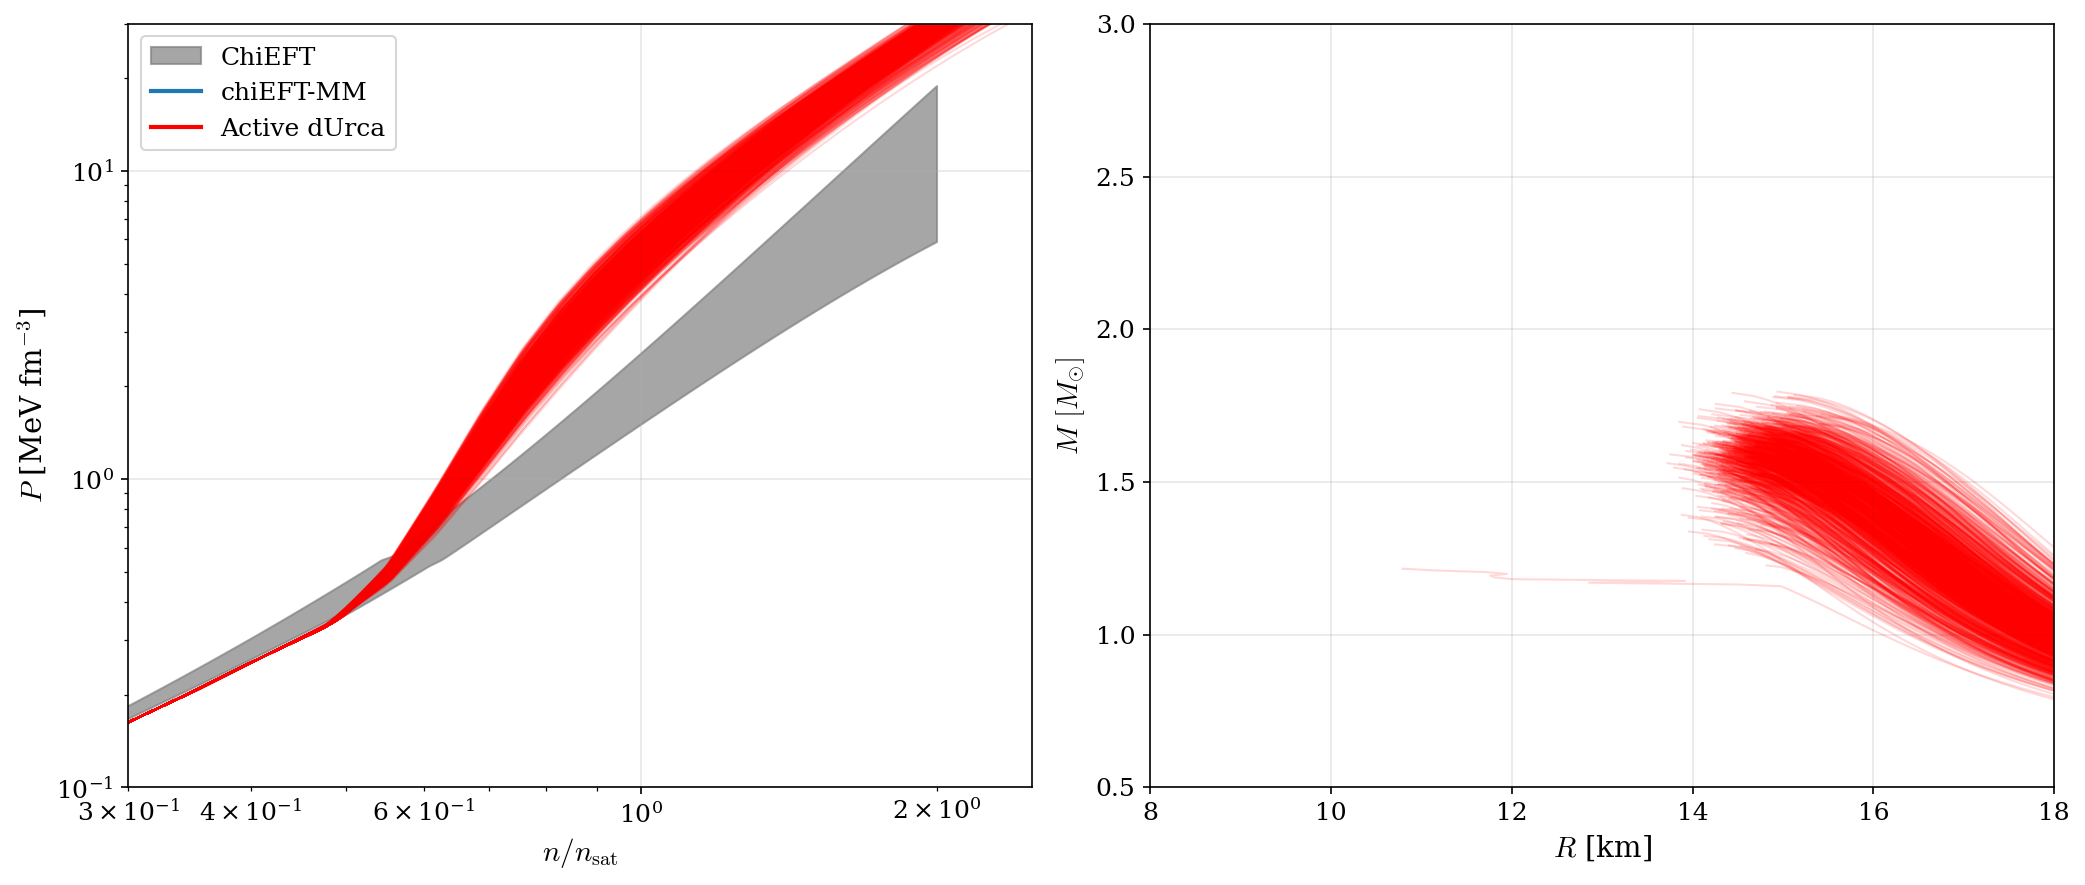

⏳ [Curves] Processing 1 inputs...


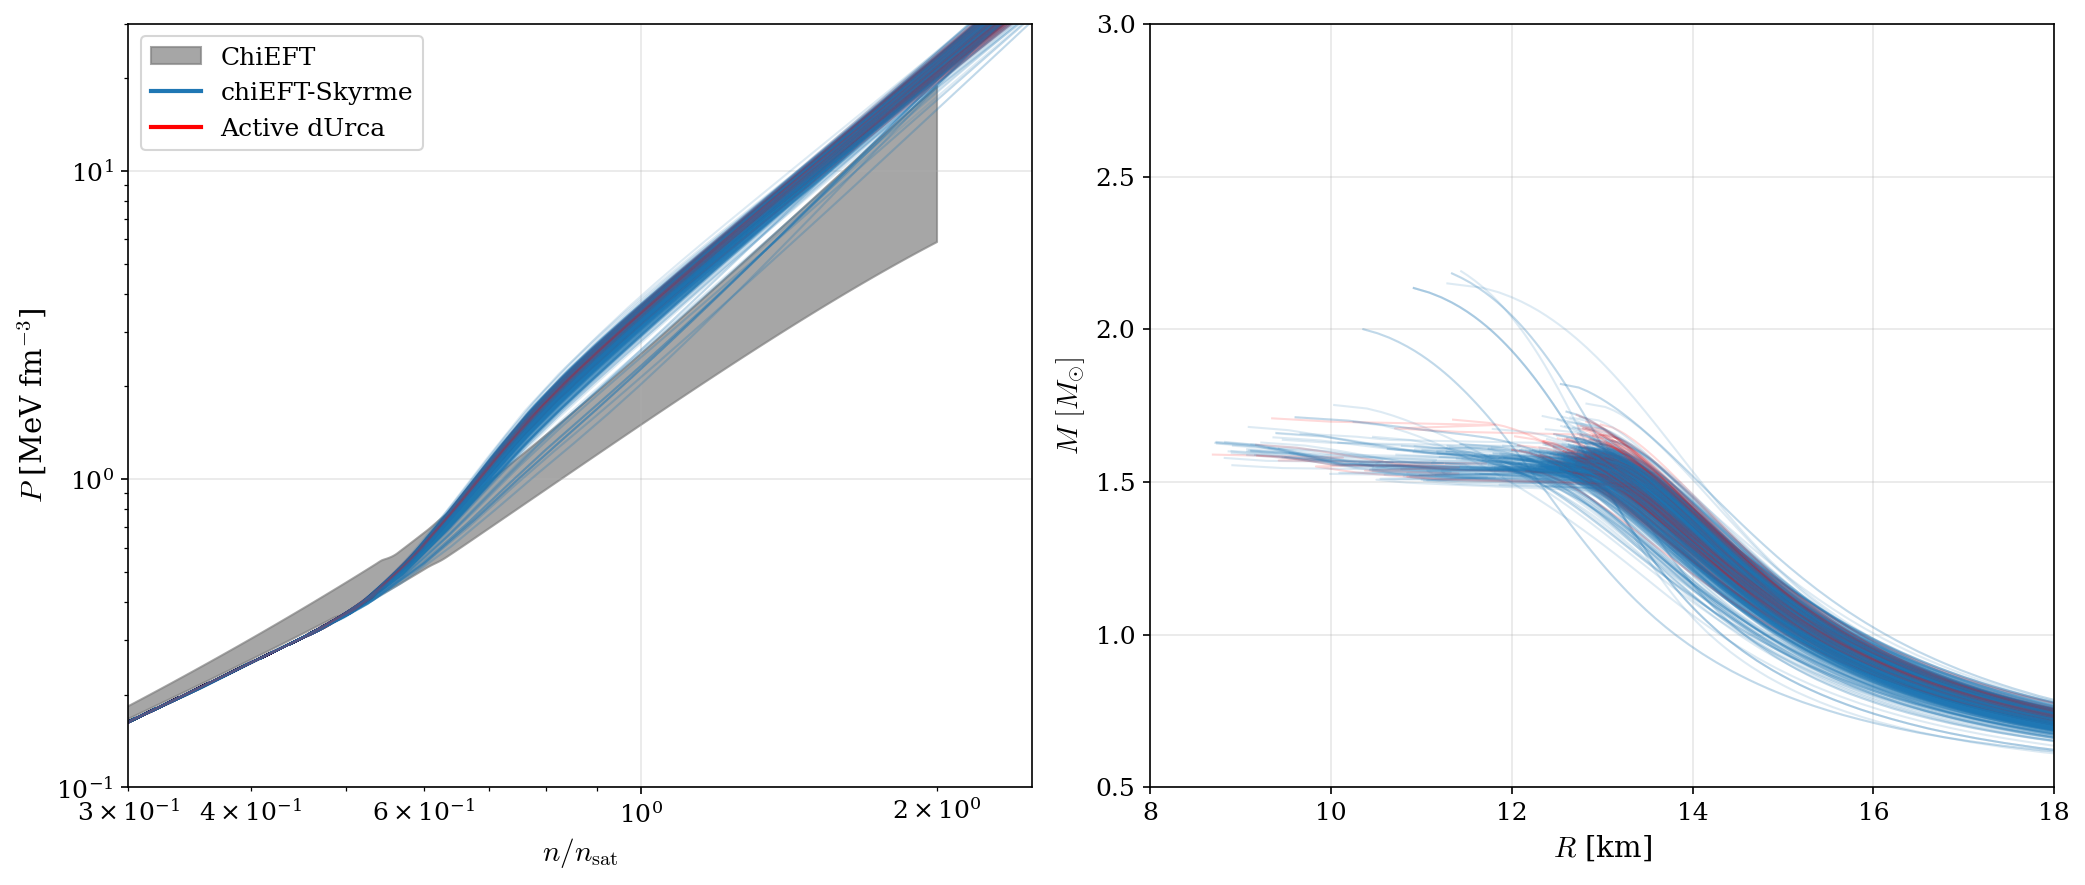

⏳ [Fractions] Processing 1 inputs...
No particle fraction data found.
⏳ [Fractions] Processing 1 inputs...


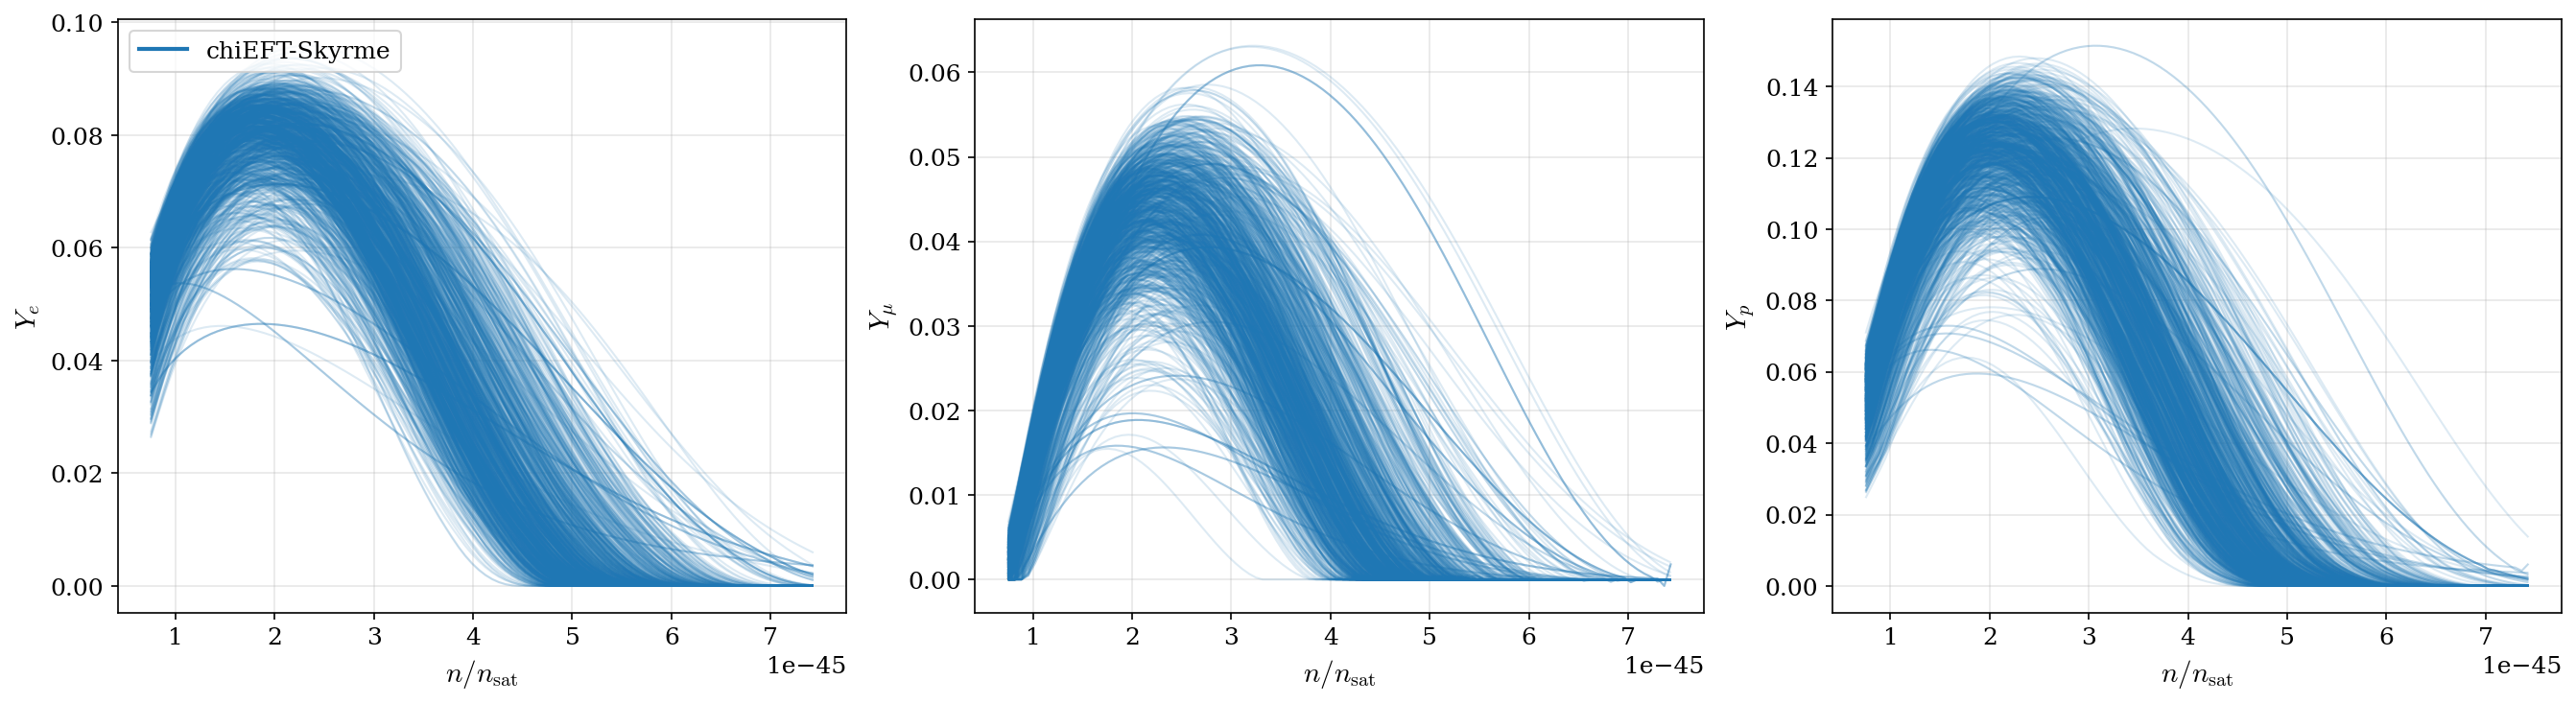

⏳ [Histograms] Processing 1 inputs...


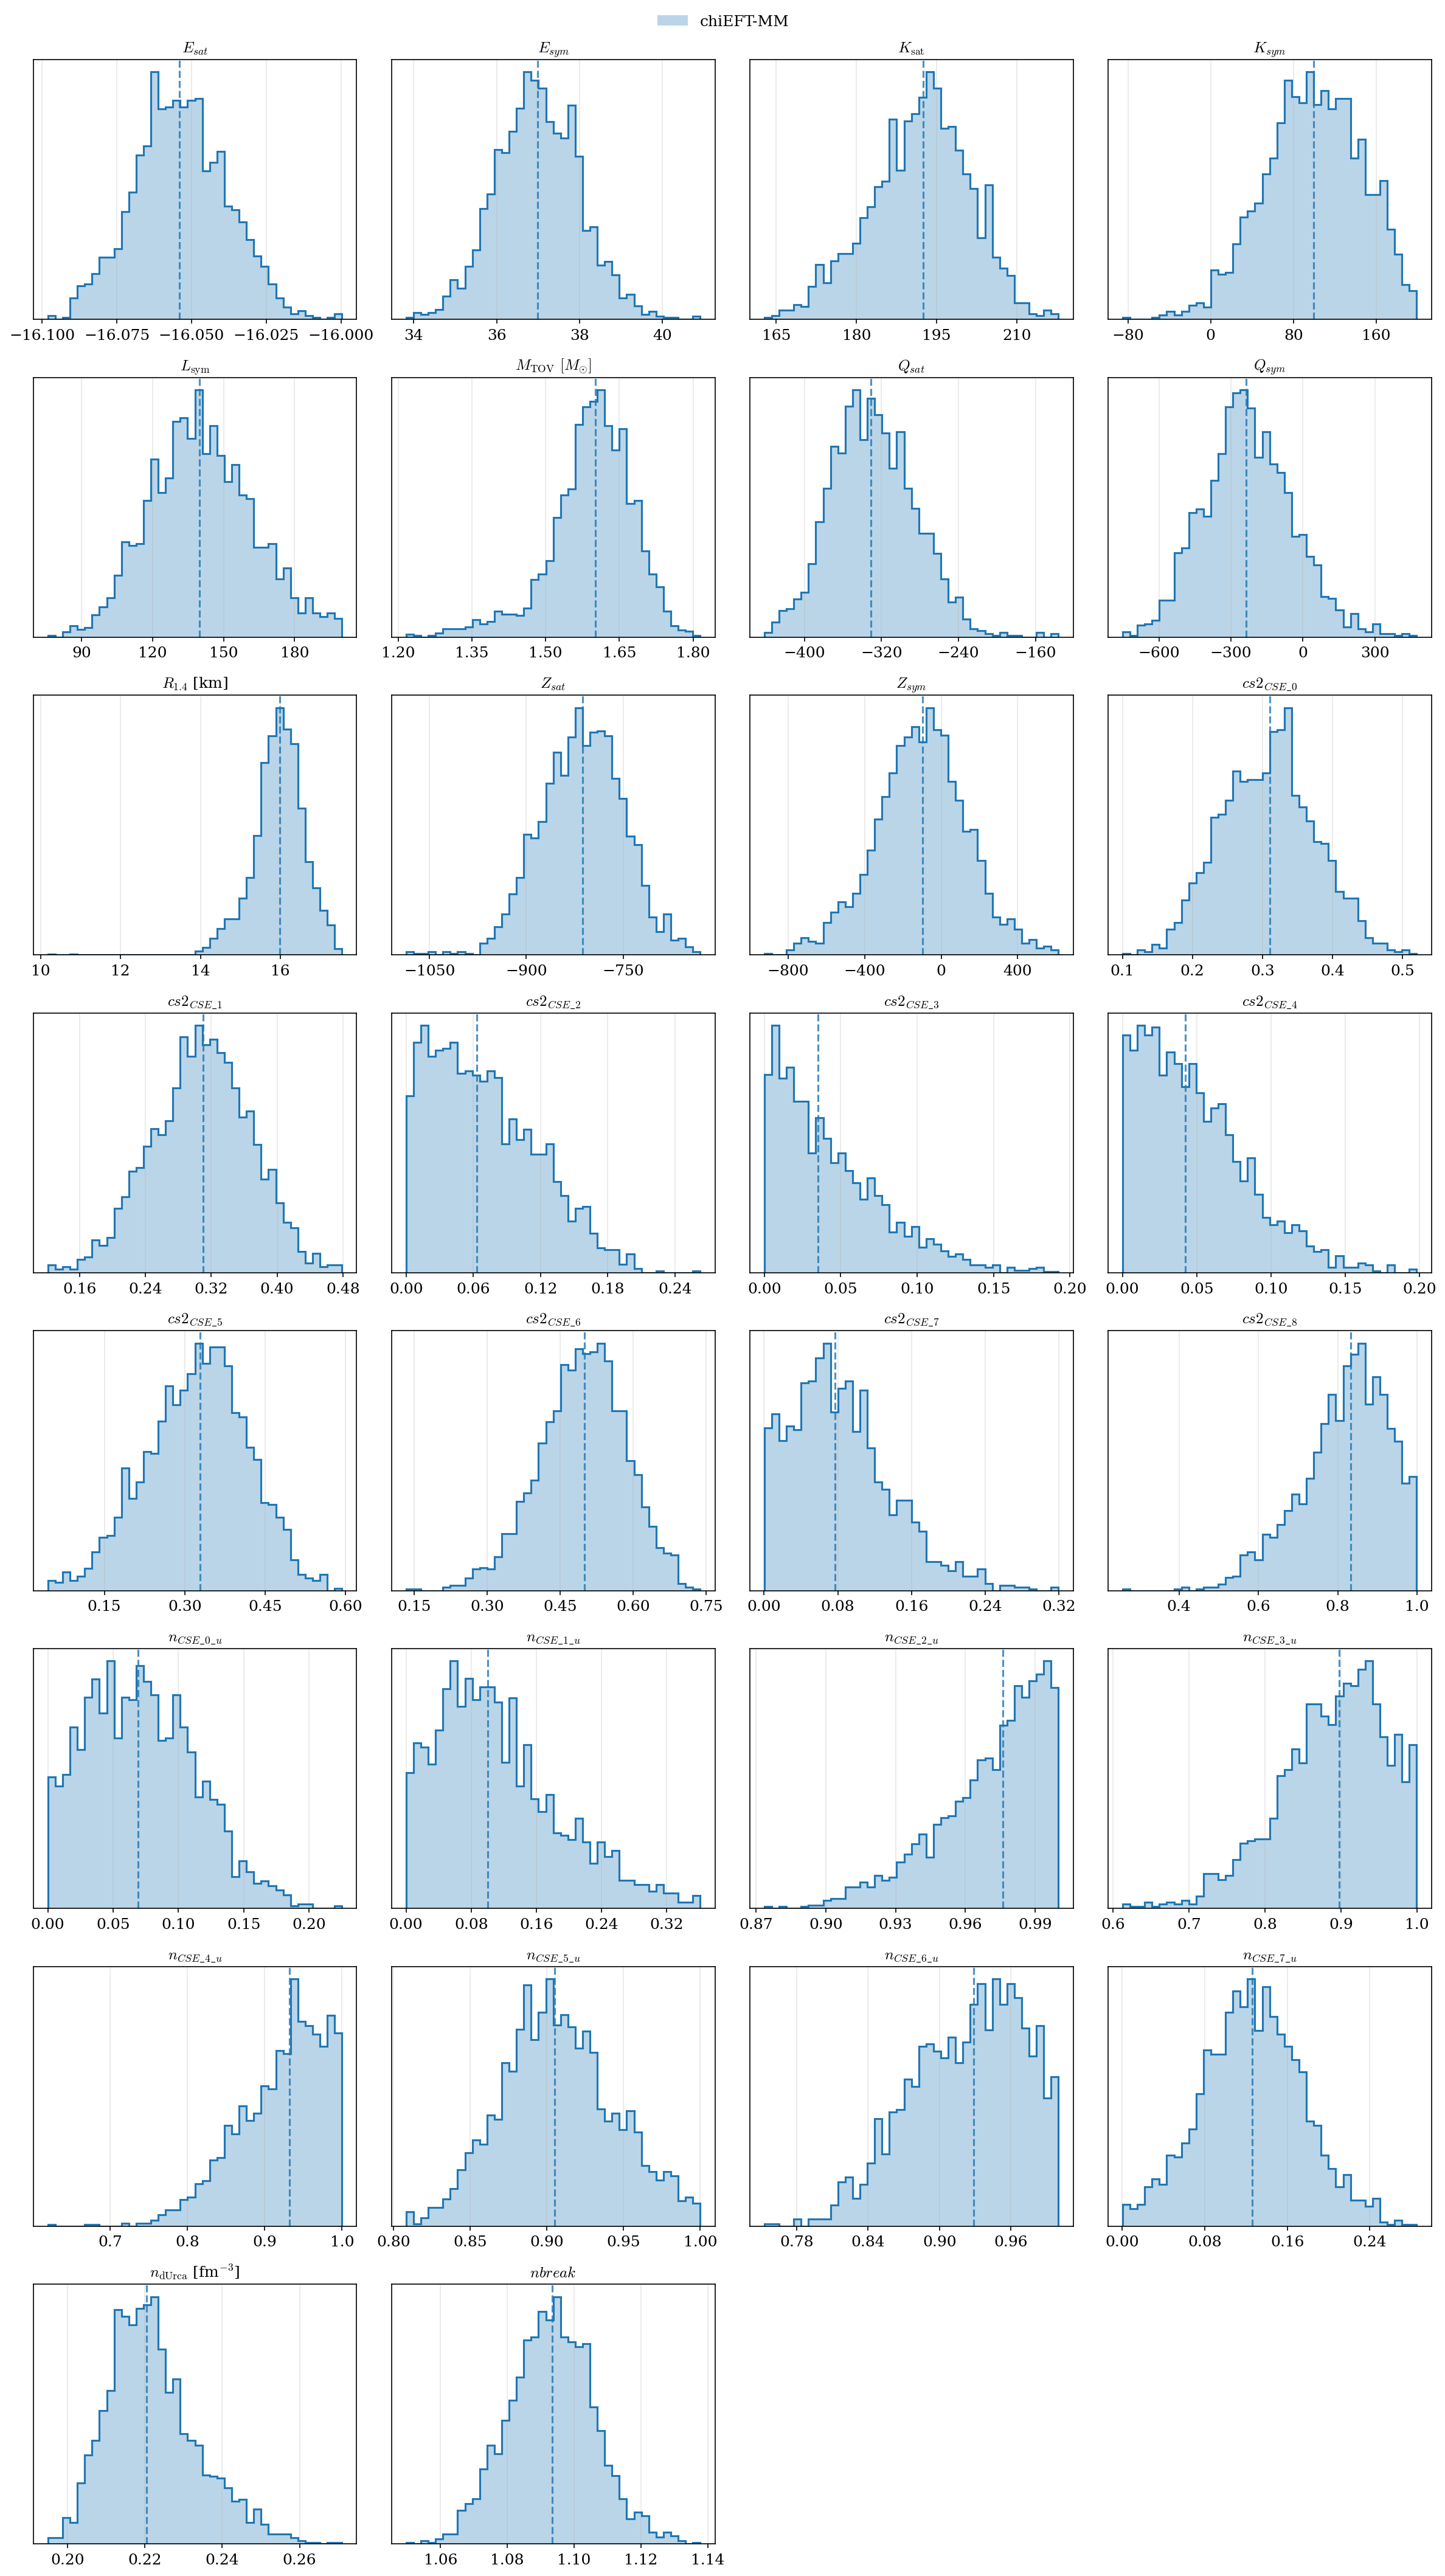

⏳ [Histograms] Processing 1 inputs...


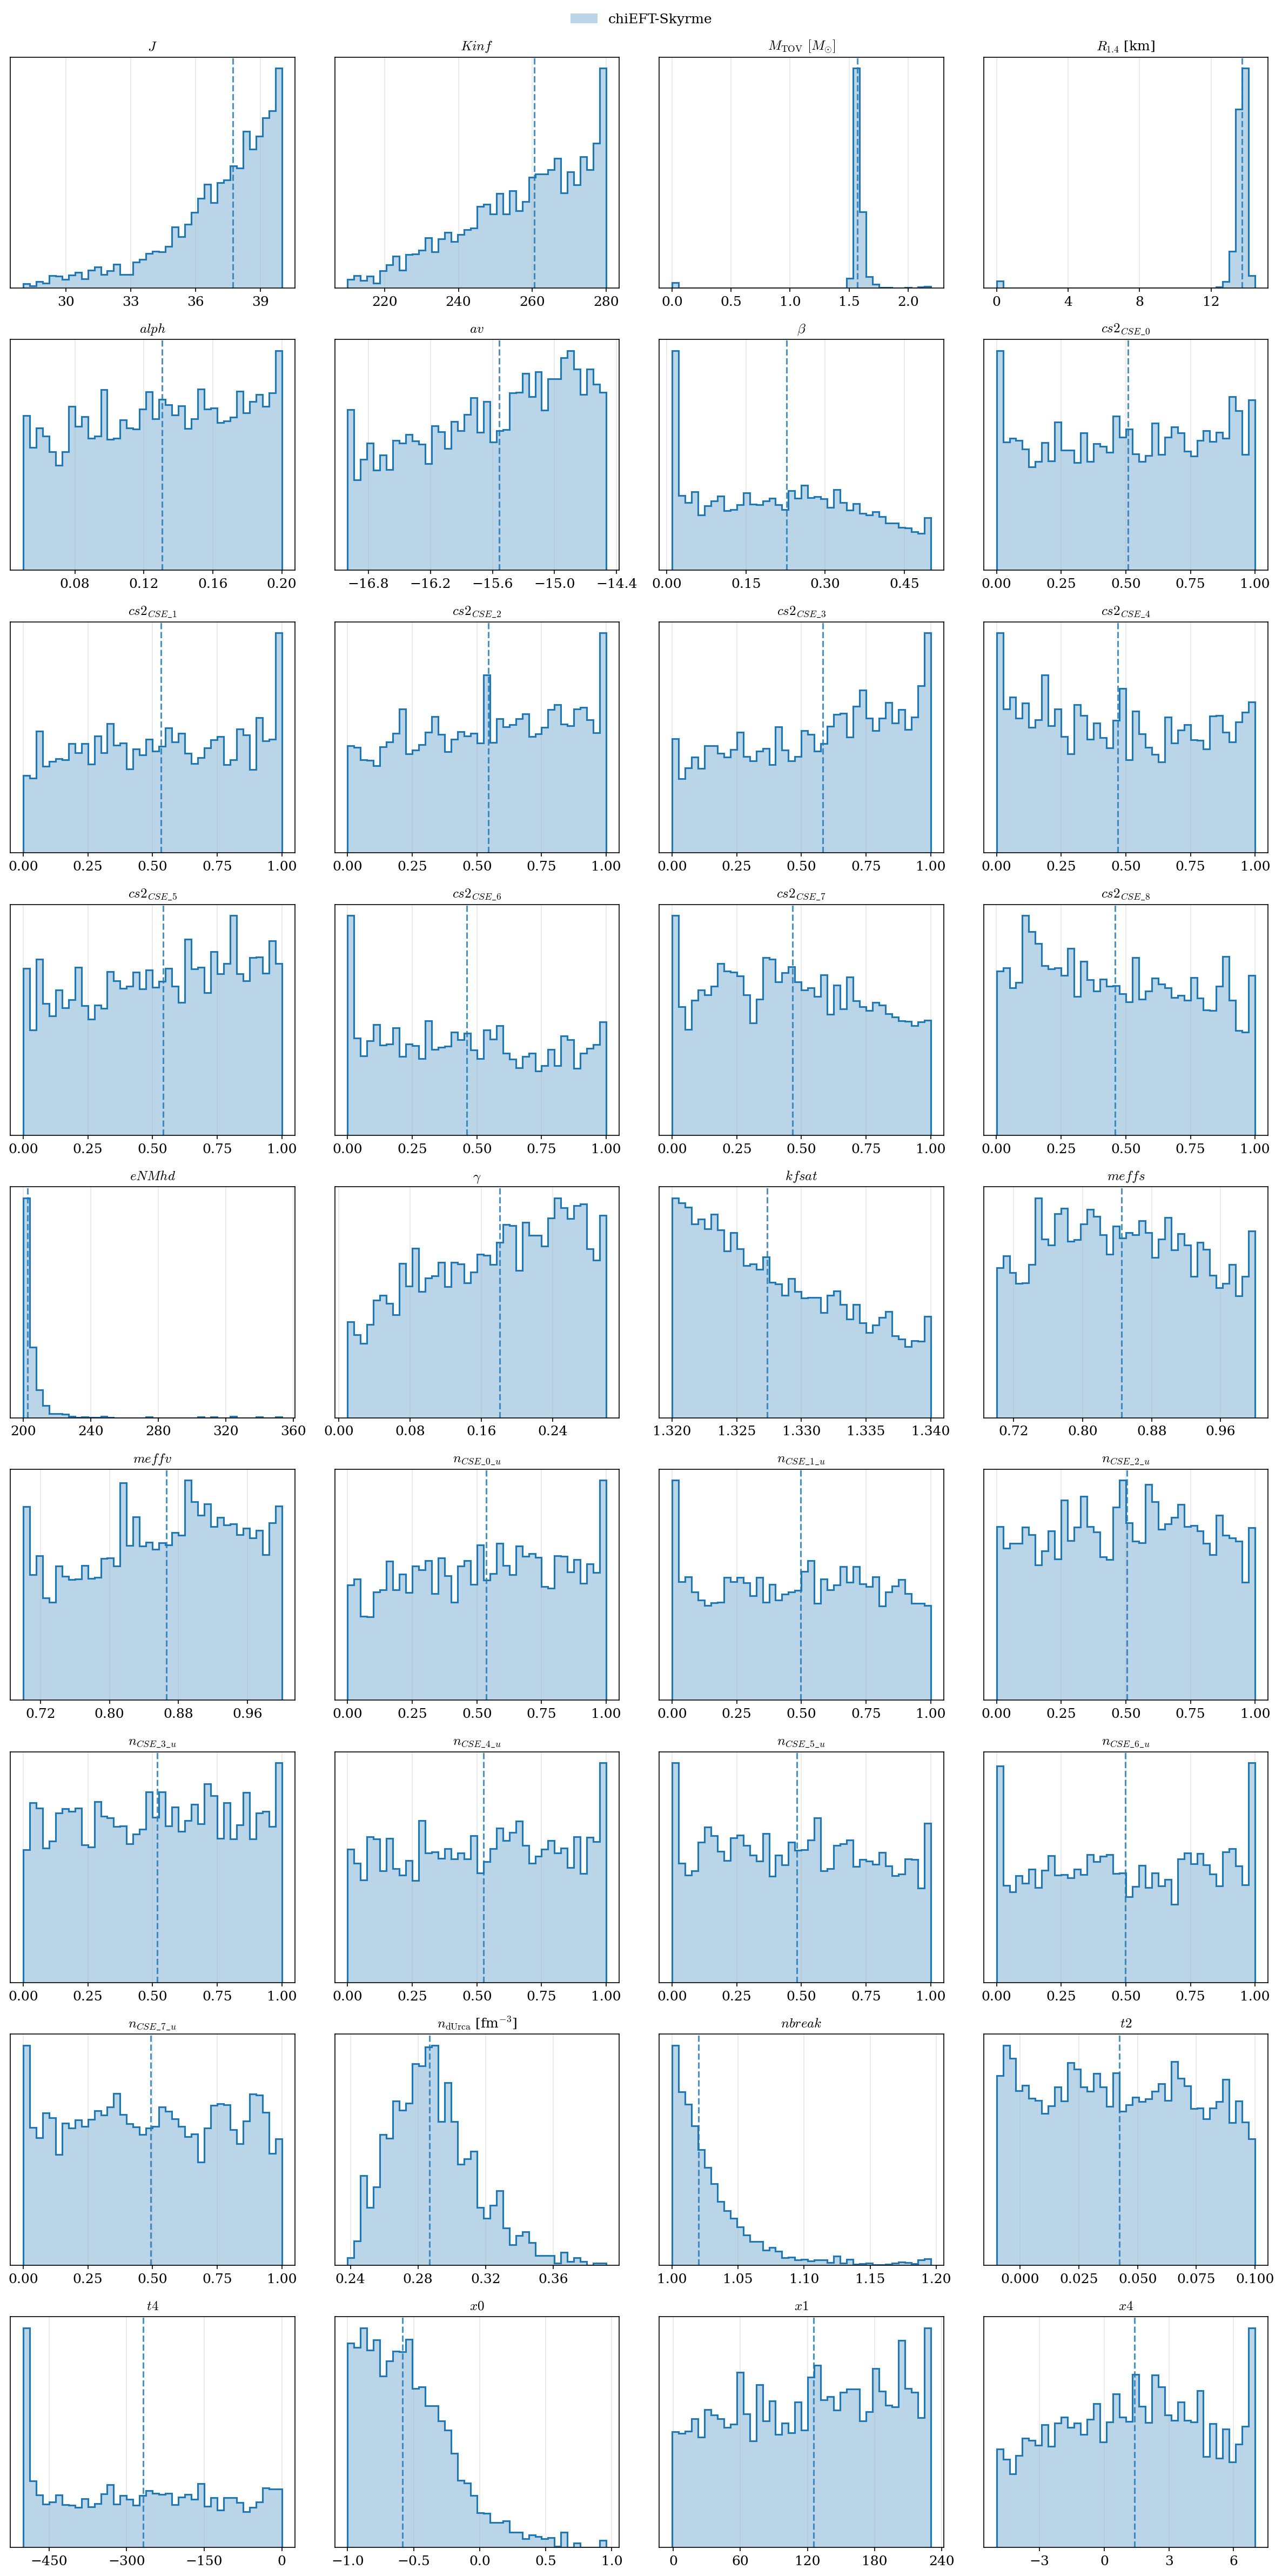

In [8]:
files_to_compare1 = [
    "smc_random_walk/chiEFT/outdir/results.h5",
]

my_labels1 = [
    "chiEFT-MM"
]
files_to_compare2 = [
    "skyrme_smc_random_walk/chiEFT-flow/outdir/results.h5",
]

my_labels2 = [
    "chiEFT-Skyrme"
]
plot_eos_curves(*files_to_compare1, labels=my_labels1)
plot_eos_curves(*files_to_compare2, labels=my_labels2)
plot_particle_fractions(*files_to_compare1, labels=my_labels1)
plot_particle_fractions(*files_to_compare2, labels=my_labels2)
compare_eos_results(*files_to_compare1, labels=my_labels1)
compare_eos_results(*files_to_compare2, labels=my_labels2)


#CAUTION: mass and radius only indicate that d urca occurs in eos, not specific to below TOV density

Loaded 2000 samples with 31 features.


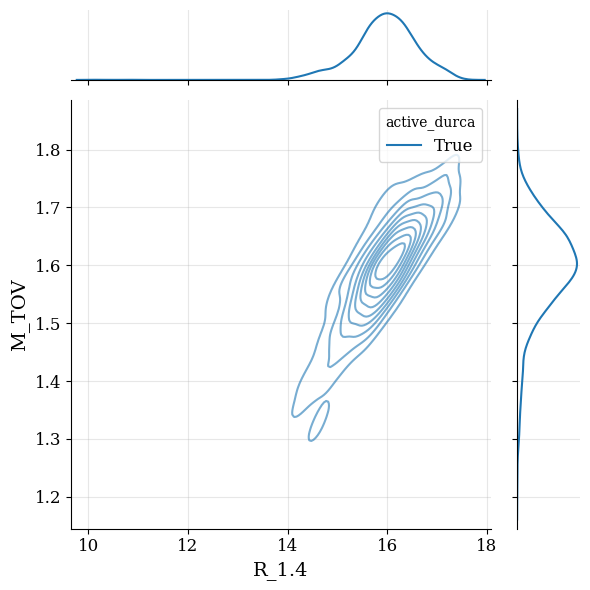

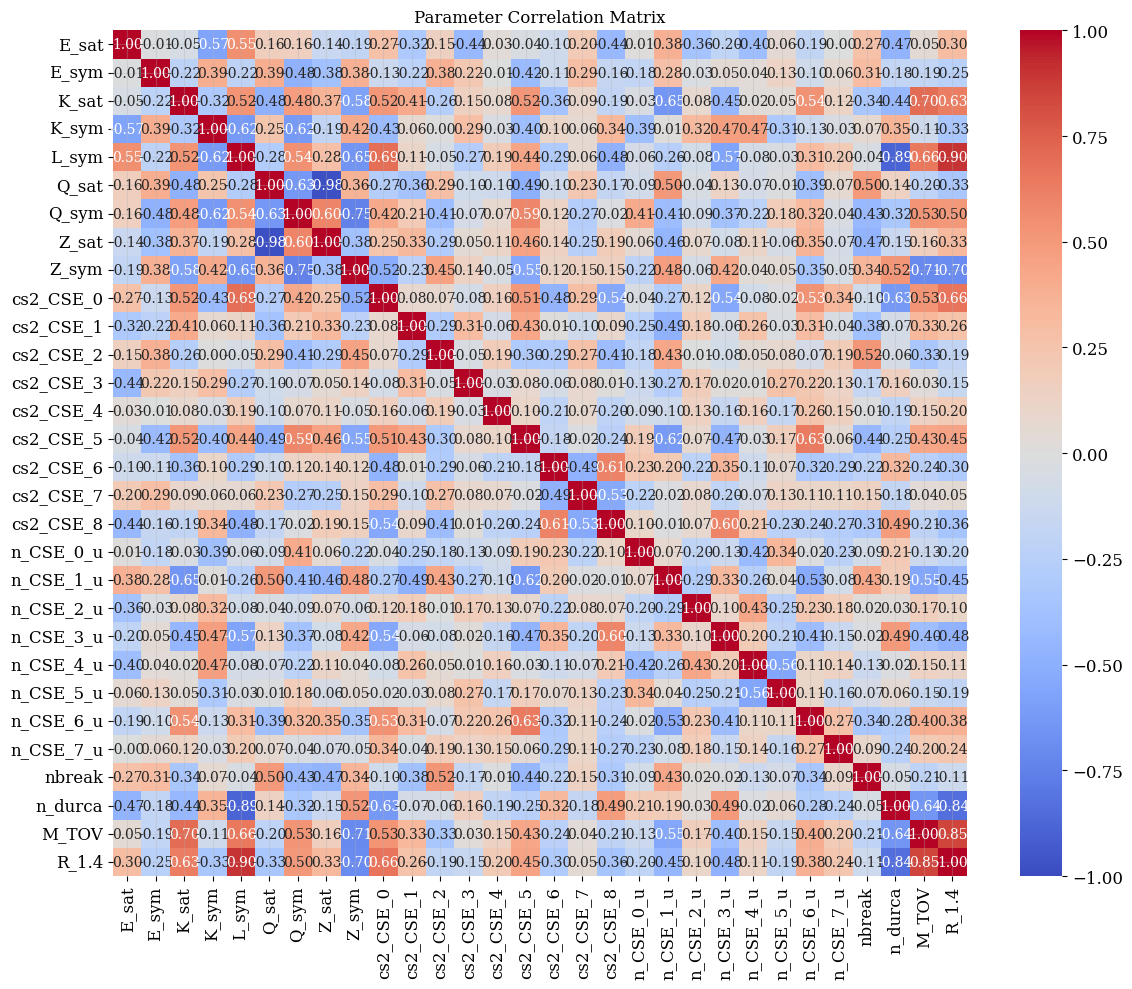

In [9]:
import numpy as np
import pandas as pd
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import logging

logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger("eos_analyzer")

class EOSAnalyzer:
    def __init__(self, filepath):
        self.filepath = Path(filepath)
        self.df = pd.DataFrame()
        self.load_data()

    def load_data(self):
        """Loads HDF5 posterior into a flat Pandas DataFrame."""
        if not self.filepath.exists():
            logger.error(f"File not found: {self.filepath}")
            return

        data_dict = {}
        with h5py.File(self.filepath, 'r') as f:
            if 'posterior' not in f:
                logger.error("No 'posterior' group in HDF5 file.")
                return
            
            post = f['posterior']
            
            # 1. Extract static parameters
            if 'parameters' in post:
                for key in post['parameters'].keys():
                    data_dict[key] = post['parameters'][key][:]
            
            # 2. Extract and reduce derived quantities
            eos_group = post.get('derived_eos', post)
            
            if 'durca_density.nb_durca' in eos_group:
                data_dict['n_durca'] = eos_group['durca_density.nb_durca'][:]
                data_dict['active_durca'] = ~np.isnan(data_dict['n_durca'])

            # Reduce mass/radius curves to scalar features (M_TOV, R_1.4)
            mass_key = 'masses_EOS' if 'masses_EOS' in eos_group else 'masses'
            rad_key = 'radii_EOS' if 'radii_EOS' in eos_group else 'radii'
            
            if mass_key in eos_group:
                masses = eos_group[mass_key][:]
                data_dict['M_TOV'] = [np.max(m) if len(m) > 0 else np.nan for m in masses]
                
                if rad_key in eos_group:
                    radii = eos_group[rad_key][:]
                    r14 = []
                    for m_arr, r_arr in zip(masses, radii):
                        if len(m_arr) > 1:
                            srt = np.argsort(m_arr)
                            r14.append(np.interp(1.4, m_arr[srt], r_arr[srt]))
                        else:
                            r14.append(np.nan)
                    data_dict['R_1.4'] = r14

        self.df = pd.DataFrame(data_dict)
        logger.info(f"Loaded {len(self.df)} samples with {len(self.df.columns)} features.")

    def get_statistics(self):
        """Returns standard statistical summary (mean, std, percentiles)."""
        if self.df.empty:
            return None
        return self.df.describe()

    def plot_pair(self, x_col, y_col, hue_col=None, kind='scatter'):
        """
        Flexible plotting for any two variables in the dataset.
        'kind' can be 'scatter', 'kde', 'hist', or 'hex'.
        """
        if x_col not in self.df.columns or y_col not in self.df.columns:
            logger.error(f"Columns missing. Available: {list(self.df.columns)}")
            return
        
        sns.jointplot(data=self.df, x=x_col, y=y_col, hue=hue_col, kind=kind, alpha=0.6)
        plt.tight_layout()
        plt.show()

    def plot_correlation_matrix(self):
        """Plots correlation heatmap for all numerical parameters."""
        if self.df.empty:
            return
            
        corr = self.df.select_dtypes(include=[np.number]).corr()
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
        plt.title("Parameter Correlation Matrix")
        plt.tight_layout()
        plt.show()

# Example Usage:
analyzer = EOSAnalyzer("smc_random_walk/chiEFT/outdir/results.h5")
stats = analyzer.get_statistics()
analyzer.plot_pair(x_col='R_1.4', y_col='M_TOV', hue_col='active_durca', kind='kde')
analyzer.plot_correlation_matrix()

In [10]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

def load_eos_to_pandas(filepath):
    """
    Parses an EOS HDF5 file into a single Pandas DataFrame.
    1D variables become scalar floats. 2D curves become NumPy arrays within the cells.
    """
    data = {}
    
    with h5py.File(filepath, 'r') as f:
        if 'posterior' not in f:
            raise KeyError(f"Group 'posterior' not found in {filepath}")
            
        post = f['posterior']
        
        # 1. Load macroscopic parameters (1D)
        if 'parameters' in post:
            for key, val in post['parameters'].items():
                data[key] = val[:]
                
        # 2. Load microscopic curves and derived parameters (1D or 2D)
        eos_group = post.get('derived_eos', post)
        for key, val in eos_group.items():
            arr = val[:]
            if arr.ndim == 1:
                data[key] = arr
            else:
                # Store 2D ragged or NaN-padded arrays as lists of 1D arrays
                data[key] = list(arr)
                
    return pd.DataFrame(data)

def plot_curve_collection(df, x_col, y_col, ax=None, **kwargs):
    """
    Rapidly plots rows of array data using Matplotlib LineCollection.
    Now with 100% less TypeError! (⁠✿⁠^⁠‿⁠^⁠)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
        
    segments = []
    
    for idx, row in df.iterrows():
        # Masalah utama: row[x_col] itu seringkali list, bukan numpy array.
        # Kita paksa jadi numpy array dulu biar bisa pake boolean masking.
        x = np.asarray(row[x_col])
        y = np.asarray(row[y_col])
        
        # Filter out NaN/Inf/Zero
        mask = np.isfinite(x) & np.isfinite(y)
        
        if np.sum(mask) > 1:
            # Slicing array pake mask (Boolean Indexing)
            segments.append(np.column_stack([x[mask], y[mask]]))
            
    if not segments:
        print("Waduh, segmen-nya kosong cuy! Cek mask lu deh.")
        return ax

    lc = LineCollection(segments, **kwargs)
    ax.add_collection(lc)
    ax.autoscale_view() # autoscale() kadang kurang gigit buat Collection
    
    return ax

             E_sat        E_sym        K_sat        K_sym        L_sym  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000   
mean    -16.053686    36.992035   191.873065    98.747701   140.909057   
std       0.015344     0.998780     9.214685    46.432960    21.793560   
min     -16.098019    33.815551   162.779359   -85.128119    75.856203   
25%     -16.063937    36.308716   185.960870    68.303791   125.661645   
50%     -16.054057    36.985267   192.471182    99.615934   139.835688   
75%     -16.042962    37.683773   198.170520   132.588736   155.421733   
max     -15.999710    40.915533   217.777163   199.058280   199.986527   

             Q_sat        Q_sym        Z_sat        Z_sym    cs2_CSE_0  ...  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000  ...   
mean   -328.439499  -227.120047  -813.901554  -104.410505     0.308458  ...   
std      43.461377   185.005548    63.581182   235.086652     0.066844  ...   
min    -441.54492

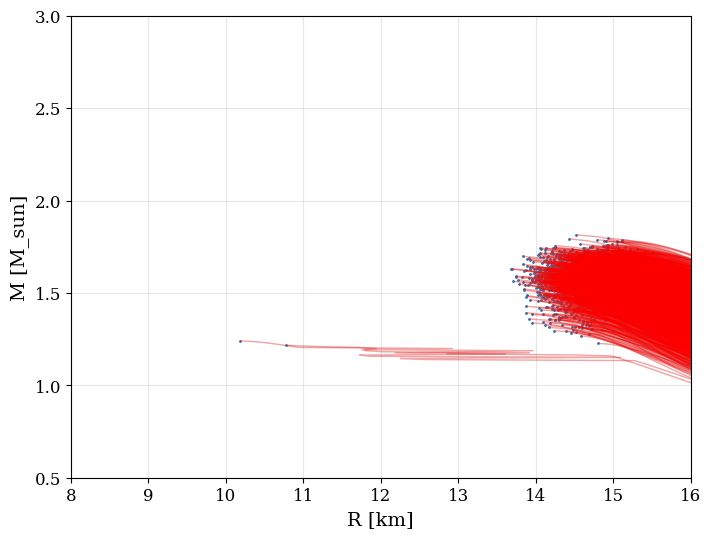

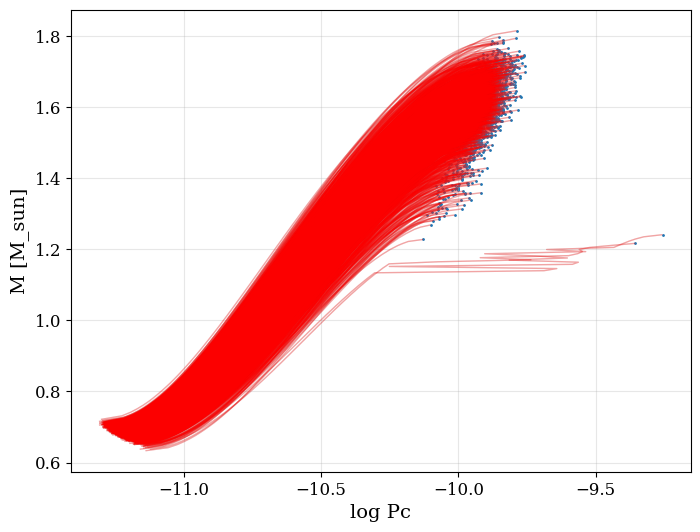

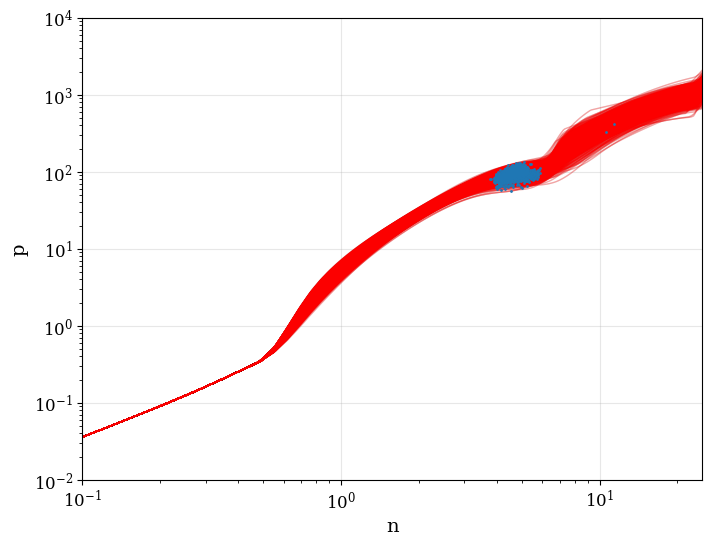

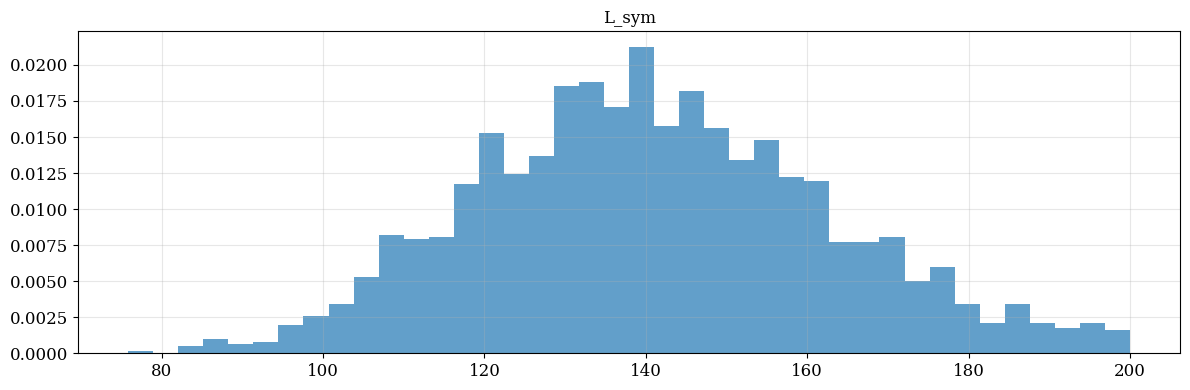

0       [0.11200273018511837, 0.11446114979693572, 0.1...
1       [0.1111111111111111, 0.11172747182180902, 0.11...
2       [0.1111111111111111, 0.1111111111111111, 0.114...
3       [0.1111111111111111, 0.1111111111111111, 0.113...
4       [0.1111111111111111, 0.1111111111111111, 0.112...
                              ...                        
1995    [0.1111111111111111, 0.1111111111111111, 0.112...
1996    [0.1111111111111111, 0.1111111111111111, 0.111...
1997    [0.1111111111111111, 0.1111111111111111, 0.113...
1998    [0.1111111111111111, 0.11115678397987315, 0.11...
1999    [0.1111111111111111, 0.1111111111111111, 0.114...
Name: DU_fraction, Length: 2000, dtype: object


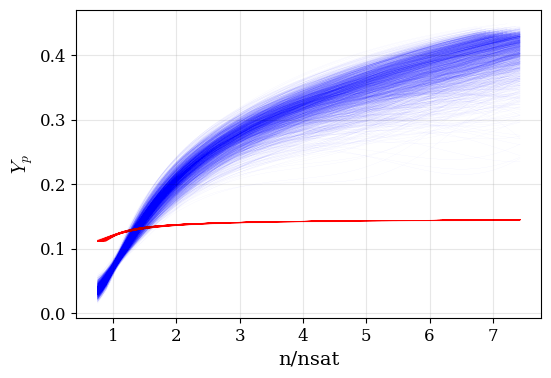

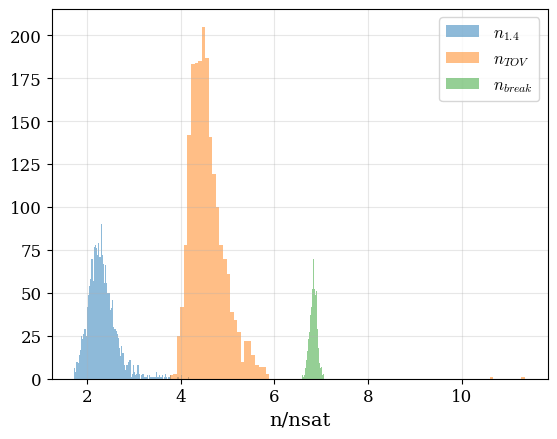

          E_sat      E_sym       K_sat       K_sym       L_sym       Q_sat  \
0    -16.055391  38.381567  192.188265   87.447219  109.638883 -361.716612   
1    -16.059883  37.845871  198.102846  133.140520  151.514281 -305.868673   
2    -16.041579  37.659081  201.684078   86.861398  172.340440 -333.664029   
3    -16.050051  35.936070  189.507013  106.028748  144.931287 -318.063088   
4    -16.056847  35.585397  194.718328   84.781291  149.129578 -337.472234   
...         ...        ...         ...         ...         ...         ...   
1995 -16.043278  36.247996  198.596752   35.060169  172.431848 -384.331118   
1996 -16.021363  35.616660  199.134480    0.169912  184.341357 -376.048785   
1997 -16.042290  37.187031  189.659514  -14.206544  171.897379 -366.561589   
1998 -16.042874  37.535808  183.827214   38.775489  158.330782 -346.779380   
1999 -16.042796  36.910754  186.333445   29.867556  153.193543 -341.387537   

           Q_sym       Z_sat       Z_sym  cs2_CSE_0  ...  \
0  

In [11]:
# 1. Ingest Data
from scipy.interpolate import interp1d
df = load_eos_to_pandas("smc_random_walk/chiEFT/outdir/results.h5")
print(df.describe())
print(df['proton_fraction'].loc[0])
df['p'] = df['p']/utils.MeV_fm_inv3_to_geometric
df['n'] = df['n']/ utils.fm_inv3_to_geometric / 0.16
df['n_metamodel_orig'] = df['n_metamodel_orig'] / 0.16

df['M_TOV'] = df['masses_EOS'].apply(max)
print(df['M_TOV'])
idx_max = df['masses_EOS'].apply(np.argmax)
df['R_TOV'] = [r_list[i] for r_list, i in zip(df['radii_EOS'], idx_max)]
print(df['R_TOV'])
df['logpc_TOV'] = [pc_list[i] for pc_list, i in zip(df['logpc_EOS'], idx_max)]
print(np.power(10,df['logpc_TOV'])/utils.MeV_fm_inv3_to_geometric)
target_p = np.power(10,df['logpc_TOV'])/utils.MeV_fm_inv3_to_geometric
df['n_TOV'] = [
    np.interp(p_target, p_list, n_list) 
    for p_target, p_list, n_list in zip(target_p, df['p'], df['n'])]
print(df['n_TOV'])

canonical_mass = 1.4

idx_14 = df['masses_EOS'].apply(
    lambda x: np.argmin(np.abs(np.array(x) - canonical_mass)) if np.max(x) >= canonical_mass else np.nan
)
df['R_14'] = [
    r_list[int(i)] if pd.notna(i) else np.nan 
    for r_list, i in zip(df['radii_EOS'], idx_14)
]
print(df['R_14'])
df['logpc_14'] = [
    pc_list[int(i)] if pd.notna(i) else np.nan 
    for pc_list, i in zip(df['logpc_EOS'], idx_14)
]
print(np.power(10,df['logpc_14'])/utils.MeV_fm_inv3_to_geometric)
target_p = np.power(10,df['logpc_14'])/utils.MeV_fm_inv3_to_geometric
df['n_14'] = [
    np.interp(p_target, p_list, n_list) 
    for p_target, p_list, n_list in zip(target_p, df['p'], df['n'])]
print(df['n_14'])


# 2. Manual Analysis and Filtering (Pandas native)
# Example: Keep only EOS with M_TOV > 2.0 and specific symmetry energy
df = df[(df['logpc_TOV'])>-11.5]

# 3. Plot M-R Curves (Highlighting direct Urca)
fig, ax = plt.subplots(figsize=(8, 6))

# Plot base valid curves in gray
plot_curve_collection(df, x_col='radii_EOS', y_col='masses_EOS', ax=ax, 
                      color='gray', alpha=0.15, linewidths=1.0)

# Isolate and plot samples where direct Urca is active in red
df_urca = df[df['durca_density.nb_durca'].notna()]
if not df_urca.empty:
    plot_curve_collection(df_urca, x_col='radii_EOS', y_col='masses_EOS', ax=ax, 
                          color='red', alpha=0.3, linewidths=1.0)
ax.scatter(df['R_TOV'],df['M_TOV'],s=1)
ax.set_xlabel("R [km]")
ax.set_ylabel("M [M_sun]")
ax.set_xlim(8, 16)
ax.set_ylim(0.5, 3.0)
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(8, 6))

# Plot base valid curves in gray
plot_curve_collection(df, x_col='logpc_EOS', y_col='masses_EOS', ax=ax, 
                      color='gray', alpha=0.15, linewidths=1.0)

# # Isolate and plot samples where direct Urca is active in red
df_urca = df[df['durca_density.nb_durca'].notna()]
if not df_urca.empty:
    plot_curve_collection(df_urca, x_col='logpc_EOS', y_col='masses_EOS', ax=ax, 
                          color='red', alpha=0.3, linewidths=1.0)
ax.scatter(df['logpc_TOV'],df['M_TOV'],s=1)
ax.set_xlabel("log Pc")
ax.set_ylabel("M [M_sun]")
# ax.set_xlim(8, 16)
# ax.set_ylim(0.5, 3.0)
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))

# Plot base valid curves in gray
plot_curve_collection(df, x_col='n', y_col='p', ax=ax, 
                      color='gray', alpha=0.15, linewidths=1.0)

# # Isolate and plot samples where direct Urca is active in red
df_urca = df[df['durca_density.nb_durca'].notna()]
if not df_urca.empty:
    plot_curve_collection(df_urca, x_col='n', y_col='p', ax=ax, 
                          color='red', alpha=0.3, linewidths=1.0)
ax.scatter(df['n_TOV'],np.power(10,df['logpc_TOV'])/utils.MeV_fm_inv3_to_geometric,s=1,zorder=5)
ax.set_xlabel("n")
ax.set_ylabel("p")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 25)
ax.set_ylim(1e-2, 1e4)
# ax.set_ylim(0.5, 3.0)
plt.show()

# 4. Plot Parameter Histograms
# Pandas built-in histogram handles this cleanly without custom loop logic
columns_to_plot = ['M_tov', 'R_1.4', 'L_sym']
available_cols = [c for c in columns_to_plot if c in df.columns]

if available_cols:
    df[available_cols].hist(bins=40, figsize=(12, 4), layout=(1, len(available_cols)), density=True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 5. Plot Particle Fractions (e.g., Ye vs density)
fig, ax = plt.subplots(figsize=(6, 4))
# e_fraction=df["e_fraction"]
# muon_fraction = 
# x_e = df["e_fraction"]/(df["e_fraction"]+df["muon_fraction"])
# df["DU_fraction"] = 1/(1+(1+np.cbrt(x_e))**3)
# Convert lists ke matrix (N_samples, N_grid)
e_frac = np.array(df["e_fraction"].tolist())
mu_frac = np.array(df["muon_fraction"].tolist())

# Itung x_e secara vectorized
x_e = e_frac / (e_frac + mu_frac)

# Itung DU_fraction pake rumus lu
# f = 1 / (1 + (1 + x_e^(1/3))^3)
du_frac_matrix = 1 / (1 + (1 + np.cbrt(x_e))**3)

# Balikin ke DataFrame sebagai list lagi kalo emang mau tetep kumuh (⁠✿⁠^⁠‿⁠^⁠)
df["DU_fraction"] = du_frac_matrix.tolist()
print(df["DU_fraction"])
# Note: Ensure 'n_Skyrme_orig' and 'e_fraction' exist in your specific HDF5

if all(col in df.columns for col in ['nbreak','n_metamodel_orig', 'proton_fraction', 'DU_fraction']):
    yp_at_ntov = []
    
    for _, row in df.iterrows():
        # Pastikan tipenya skalar, bukan list/array 1 elemen
        n_tov_val = float(row['n_TOV'])
        n_break_val = float(row['nbreak'])
        
        # Eksekusi filter (misal lu mau yang < n_break)
        if n_tov_val < n_break_val:
            # Baru kita interpolate
            val = np.interp(n_tov_val, row['n_metamodel_orig'], row['proton_fraction'], left=np.nan, right=np.nan)
            yp_at_ntov.append(val)
        else:
            yp_at_ntov.append(np.nan)
    plot_curve_collection(df, x_col='n_metamodel_orig', y_col='proton_fraction', ax=ax, 
                          color='blue', alpha=0.1, linewidths=0.1)
    plot_curve_collection(df, x_col='n_metamodel_orig', y_col='DU_fraction', ax=ax, 
                          color='red', alpha=0.1, linewidths=0.1)
    ax.scatter(df['n_TOV'], yp_at_ntov, color='red', s=1, label=r'$Y_p$ at $M_{max}$', alpha = 0.8, zorder=5)
    ax.set_xlabel("n/nsat")
    ax.set_ylabel(r"$Y_p$")
    plt.show()
plt.close()    


if all(col in df.columns for col in ['nbreak','n_metamodel_orig', 'proton_fraction', 'DU_fraction']):
    yp_at_n14 = []
    
    for _, row in df.iterrows():
        # Pastikan tipenya skalar, bukan list/array 1 elemen
        n_14_val = float(row['n_14'])
        n_break_val = float(row['nbreak'])
        
        # Eksekusi filter (misal lu mau yang < n_break)
        if n_14_val < n_break_val:
            # Baru kita interpolate
            val = np.interp(n_14_val, row['n_metamodel_orig'], row['proton_fraction'], left=np.nan, right=np.nan)
            yp_at_n14.append(val)
        else:
            yp_at_n14.append(np.nan)
    plot_curve_collection(df, x_col='n_metamodel_orig', y_col='proton_fraction', ax=ax, 
                          color='blue', alpha=0.1, linewidths=0.1)
    plot_curve_collection(df, x_col='n_metamodel_orig', y_col='DU_fraction', ax=ax, 
                          color='red', alpha=0.1, linewidths=0.1)
    ax.scatter(df['n_14'], yp_at_n14, color='red', s=1, label=r'$Y_p$ at $M_{max}$', alpha = 0.8, zorder=5)
    ax.set_xlabel("n/nsat")
    ax.set_ylabel(r"$Y_p$")
    plt.show()
plt.close()    
plt.hist(df['n_14'], label = r'$n_{1.4}$', alpha = 0.5, bins=100)
plt.hist(df['n_TOV'],  label = r'$n_{TOV}$', alpha = 0.5, bins=100)
plt.hist(df['nbreak']/0.16,  label = r'$n_{break}$', alpha = 0.5, bins=100)
plt.xlabel("n/nsat")
plt.legend()
plt.show()
print(df)

In [12]:
import h5py

def read_log_evidence(h5file: h5py.File) -> tuple[float, float] | None:
    # We access the 'metadata' group directly
    if "metadata" not in h5file:
        return None
    
    attrs = h5file["metadata"].attrs
    
    if "logZ" not in attrs:
        return None
        
    logZ = float(attrs["logZ"])
    # Handle the error term safely
    logZ_err = float(attrs.get("logZ_err", 0.0))
    
    return logZ, logZ_err

# THE FIX: Open the file using a context manager!
file_path = "smc_random_walk/chiEFT/outdir/results.h5"

with h5py.File(file_path, "r") as f:
    evidence = read_log_evidence(f)
    print(evidence)

(nan, 0.0)


                 J         Kinf         alph           av         beta  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean     34.035200   239.542099     0.127469   -15.811144     0.252914   
std       3.463624    19.965756     0.043597     0.721777     0.139970   
min      28.000730   210.105674     0.050007   -16.999318     0.010210   
25%      30.972317   222.109944     0.089323   -16.452681     0.128151   
50%      34.047798   236.402331     0.130182   -15.842798     0.253439   
75%      36.940084   256.164891     0.165553   -15.218925     0.374016   
max      39.994567   279.904805     0.199990   -14.502478     0.499824   

         cs2_CSE_0    cs2_CSE_1    cs2_CSE_2    cs2_CSE_3    cs2_CSE_4  ...  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000  ...   
mean      0.505642     0.480056     0.495684     0.493711     0.509080  ...   
std       0.281471     0.286395     0.286034     0.291439     0.285173  ...   
min       0.00331

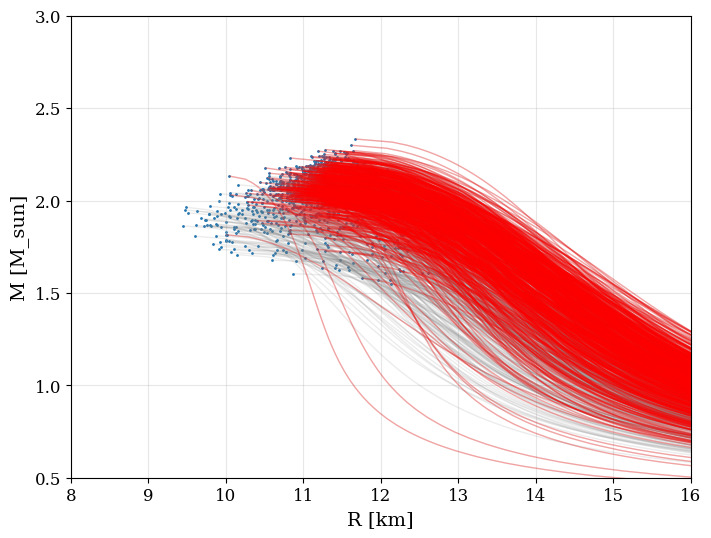

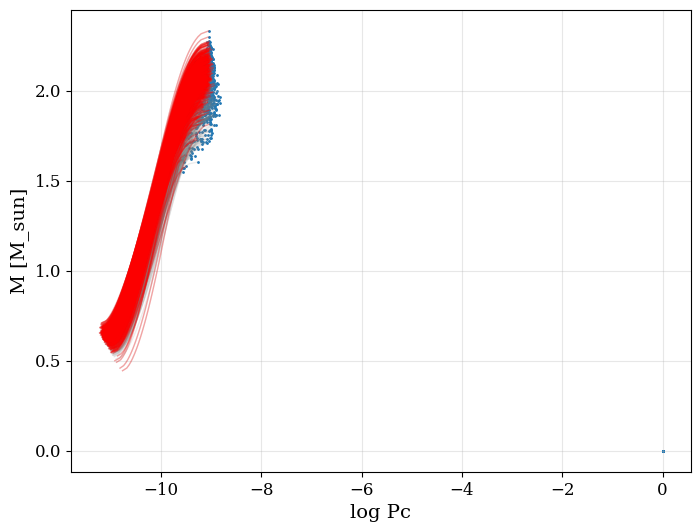

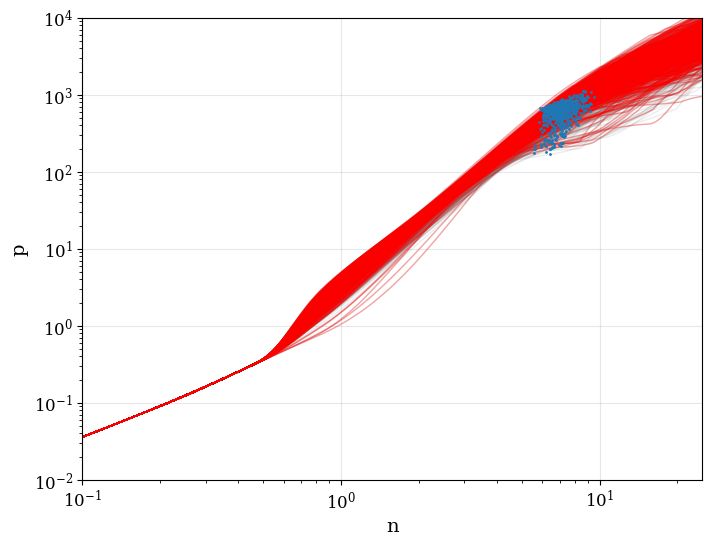

0      [0.1111111111111111, 0.1111111111111111, 0.111...
1      [0.1111111111111111, 0.1111111111111111, 0.112...
2      [0.1111111111111111, 0.1111111111111111, 0.111...
3      [0.11401405091354007, 0.11625778482804752, 0.1...
4      [0.11123611345706537, 0.11301145672128429, 0.1...
                             ...                        
995    [0.1111111111111111, 0.11194683968486244, 0.11...
996    [0.1111111111111111, 0.1111111111111111, 0.111...
997    [0.1111111111111111, 0.1111111111111111, 0.111...
998    [0.1111111111111111, 0.1111111111111111, 0.111...
999    [0.1111111111111111, 0.11138422905040789, 0.11...
Name: DU_fraction, Length: 1000, dtype: object


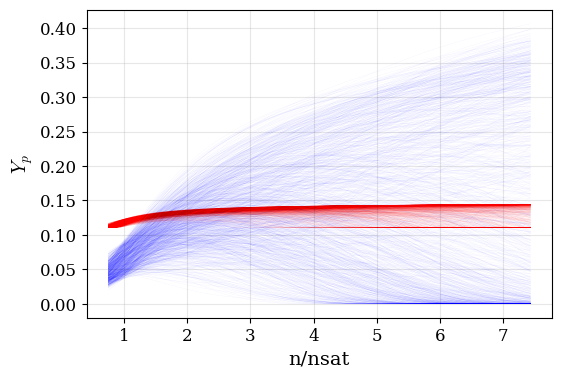

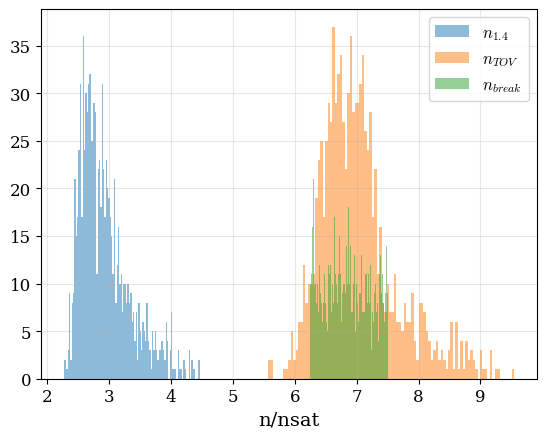

             J        Kinf      alph         av      beta  cs2_CSE_0  \
0    28.612299  223.618723  0.086771 -15.710765  0.297246   0.601532   
1    32.677491  211.948159  0.172061 -15.199983  0.182260   0.979611   
2    30.497845  271.713030  0.187500 -16.541187  0.308334   0.230536   
3    37.797014  225.756956  0.086867 -15.806067  0.013796   0.044550   
4    34.004664  222.614805  0.098973 -16.043908  0.134993   0.770337   
..         ...         ...       ...        ...       ...        ...   
995  32.063691  233.199221  0.131982 -15.712691  0.210028   0.885673   
996  30.209151  217.955894  0.158072 -16.027809  0.411222   0.817023   
997  30.199140  256.828432  0.050709 -15.358589  0.114664   0.466323   
998  30.513242  261.550791  0.053976 -15.301051  0.319368   0.512284   
999  29.448615  239.504340  0.085832 -15.957882  0.382886   0.938206   

     cs2_CSE_1  cs2_CSE_2  cs2_CSE_3  cs2_CSE_4  ...  \
0     0.555362   0.030618   0.064196   0.952122  ...   
1     0.285321   0.8397

In [13]:
# 1. Ingest Data
from scipy.interpolate import interp1d
df = load_eos_to_pandas("skyrme_smc_random_walk/prior/outdir/results.h5")
print(df.describe())
print(df['proton_fraction'].loc[0])
df['p'] = df['p']/utils.MeV_fm_inv3_to_geometric
df['n'] = df['n']/ utils.fm_inv3_to_geometric / 0.16
df['n_metamodel_orig'] = df['n_Skyrme_orig'] / 0.16

df['M_TOV'] = df['masses_EOS'].apply(max)
print(df['M_TOV'])
idx_max = df['masses_EOS'].apply(np.argmax)
df['R_TOV'] = [r_list[i] for r_list, i in zip(df['radii_EOS'], idx_max)]
print(df['R_TOV'])
df['logpc_TOV'] = [pc_list[i] for pc_list, i in zip(df['logpc_EOS'], idx_max)]
print(np.power(10,df['logpc_TOV'])/utils.MeV_fm_inv3_to_geometric)
target_p = np.power(10,df['logpc_TOV'])/utils.MeV_fm_inv3_to_geometric
df['n_TOV'] = [
    np.interp(p_target, p_list, n_list) 
    for p_target, p_list, n_list in zip(target_p, df['p'], df['n'])]
print(df['n_TOV'])

canonical_mass = 1.4

idx_14 = df['masses_EOS'].apply(
    lambda x: np.argmin(np.abs(np.array(x) - canonical_mass)) if np.max(x) >= canonical_mass else np.nan
)
df['R_14'] = [
    r_list[int(i)] if pd.notna(i) else np.nan 
    for r_list, i in zip(df['radii_EOS'], idx_14)
]
print(df['R_14'])
df['logpc_14'] = [
    pc_list[int(i)] if pd.notna(i) else np.nan 
    for pc_list, i in zip(df['logpc_EOS'], idx_14)
]
print(np.power(10,df['logpc_14'])/utils.MeV_fm_inv3_to_geometric)
target_p = np.power(10,df['logpc_14'])/utils.MeV_fm_inv3_to_geometric
df['n_14'] = [
    np.interp(p_target, p_list, n_list) 
    for p_target, p_list, n_list in zip(target_p, df['p'], df['n'])]
print(df['n_14'])


# 2. Manual Analysis and Filtering (Pandas native)
# Example: Keep only EOS with M_TOV > 2.0 and specific symmetry energy
df = df[(df['logpc_TOV'])>-11.5]

# 3. Plot M-R Curves (Highlighting direct Urca)
fig, ax = plt.subplots(figsize=(8, 6))

# Plot base valid curves in gray
plot_curve_collection(df, x_col='radii_EOS', y_col='masses_EOS', ax=ax, 
                      color='gray', alpha=0.15, linewidths=1.0)

# Isolate and plot samples where direct Urca is active in red
df_urca = df[df['durca_density.nb_durca'].notna()]
if not df_urca.empty:
    plot_curve_collection(df_urca, x_col='radii_EOS', y_col='masses_EOS', ax=ax, 
                          color='red', alpha=0.3, linewidths=1.0)
ax.scatter(df['R_TOV'],df['M_TOV'],s=1)
ax.set_xlabel("R [km]")
ax.set_ylabel("M [M_sun]")
ax.set_xlim(8, 16)
ax.set_ylim(0.5, 3.0)
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(8, 6))

# Plot base valid curves in gray
plot_curve_collection(df, x_col='logpc_EOS', y_col='masses_EOS', ax=ax, 
                      color='gray', alpha=0.15, linewidths=1.0)

# # Isolate and plot samples where direct Urca is active in red
df_urca = df[df['durca_density.nb_durca'].notna()]
if not df_urca.empty:
    plot_curve_collection(df_urca, x_col='logpc_EOS', y_col='masses_EOS', ax=ax, 
                          color='red', alpha=0.3, linewidths=1.0)
ax.scatter(df['logpc_TOV'],df['M_TOV'],s=1)
ax.set_xlabel("log Pc")
ax.set_ylabel("M [M_sun]")
# ax.set_xlim(8, 16)
# ax.set_ylim(0.5, 3.0)
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))

# Plot base valid curves in gray
plot_curve_collection(df, x_col='n', y_col='p', ax=ax, 
                      color='gray', alpha=0.15, linewidths=1.0)

# # Isolate and plot samples where direct Urca is active in red
df_urca = df[df['durca_density.nb_durca'].notna()]
if not df_urca.empty:
    plot_curve_collection(df_urca, x_col='n', y_col='p', ax=ax, 
                          color='red', alpha=0.3, linewidths=1.0)
ax.scatter(df['n_TOV'],np.power(10,df['logpc_TOV'])/utils.MeV_fm_inv3_to_geometric,s=1,zorder=5)
ax.set_xlabel("n")
ax.set_ylabel("p")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-1, 25)
ax.set_ylim(1e-2, 1e4)
# ax.set_ylim(0.5, 3.0)
plt.show()

# 4. Plot Parameter Histograms
# Pandas built-in histogram handles this cleanly without custom loop logic
columns_to_plot = ['M_tov', 'R_1.4', 'L_sym']
available_cols = [c for c in columns_to_plot if c in df.columns]

if available_cols:
    df[available_cols].hist(bins=40, figsize=(12, 4), layout=(1, len(available_cols)), density=True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 5. Plot Particle Fractions (e.g., Ye vs density)
fig, ax = plt.subplots(figsize=(6, 4))
# e_fraction=df["e_fraction"]
# muon_fraction = 
# x_e = df["e_fraction"]/(df["e_fraction"]+df["muon_fraction"])
# df["DU_fraction"] = 1/(1+(1+np.cbrt(x_e))**3)
# Convert lists ke matrix (N_samples, N_grid)
e_frac = np.array(df["e_fraction"].tolist())
mu_frac = np.array(df["muon_fraction"].tolist())

# Itung x_e secara vectorized
x_e = e_frac / (e_frac + mu_frac)

# Itung DU_fraction pake rumus lu
# f = 1 / (1 + (1 + x_e^(1/3))^3)
du_frac_matrix = 1 / (1 + (1 + np.cbrt(x_e))**3)

# Balikin ke DataFrame sebagai list lagi kalo emang mau tetep kumuh (⁠✿⁠^⁠‿⁠^⁠)
df["DU_fraction"] = du_frac_matrix.tolist()
print(df["DU_fraction"])
# Note: Ensure 'n_Skyrme_orig' and 'e_fraction' exist in your specific HDF5

if all(col in df.columns for col in ['nbreak','n_metamodel_orig', 'proton_fraction', 'DU_fraction']):
    yp_at_ntov = []
    
    for _, row in df.iterrows():
        # Pastikan tipenya skalar, bukan list/array 1 elemen
        n_tov_val = float(row['n_TOV'])
        n_break_val = float(row['nbreak'])
        
        # Eksekusi filter (misal lu mau yang < n_break)
        if n_tov_val < n_break_val:
            # Baru kita interpolate
            val = np.interp(n_tov_val, row['n_metamodel_orig'], row['proton_fraction'], left=np.nan, right=np.nan)
            yp_at_ntov.append(val)
        else:
            yp_at_ntov.append(np.nan)
    plot_curve_collection(df, x_col='n_metamodel_orig', y_col='proton_fraction', ax=ax, 
                          color='blue', alpha=0.1, linewidths=0.1)
    plot_curve_collection(df, x_col='n_metamodel_orig', y_col='DU_fraction', ax=ax, 
                          color='red', alpha=0.1, linewidths=0.1)
    ax.scatter(df['n_TOV'], yp_at_ntov, color='red', s=1, label=r'$Y_p$ at $M_{max}$', alpha = 0.8, zorder=5)
    ax.set_xlabel("n/nsat")
    ax.set_ylabel(r"$Y_p$")
    plt.show()
plt.close()    


if all(col in df.columns for col in ['nbreak','n_metamodel_orig', 'proton_fraction', 'DU_fraction']):
    yp_at_n14 = []
    
    for _, row in df.iterrows():
        # Pastikan tipenya skalar, bukan list/array 1 elemen
        n_14_val = float(row['n_14'])
        n_break_val = float(row['nbreak'])
        
        # Eksekusi filter (misal lu mau yang < n_break)
        if n_14_val < n_break_val:
            # Baru kita interpolate
            val = np.interp(n_14_val, row['n_metamodel_orig'], row['proton_fraction'], left=np.nan, right=np.nan)
            yp_at_n14.append(val)
        else:
            yp_at_n14.append(np.nan)
    plot_curve_collection(df, x_col='n_metamodel_orig', y_col='proton_fraction', ax=ax, 
                          color='blue', alpha=0.1, linewidths=0.1)
    plot_curve_collection(df, x_col='n_metamodel_orig', y_col='DU_fraction', ax=ax, 
                          color='red', alpha=0.1, linewidths=0.1)
    ax.scatter(df['n_14'], yp_at_n14, color='red', s=1, label=r'$Y_p$ at $M_{max}$', alpha = 0.8, zorder=5)
    ax.set_xlabel("n/nsat")
    ax.set_ylabel(r"$Y_p$")
    plt.show()
plt.close()    
plt.hist(df['n_14'], label = r'$n_{1.4}$', alpha = 0.5, bins=100)
plt.hist(df['n_TOV'],  label = r'$n_{TOV}$', alpha = 0.5, bins=100)
plt.hist(df['nbreak']/0.16,  label = r'$n_{break}$', alpha = 0.5, bins=100)
plt.xlabel("n/nsat")
plt.legend()
plt.show()
print(df)

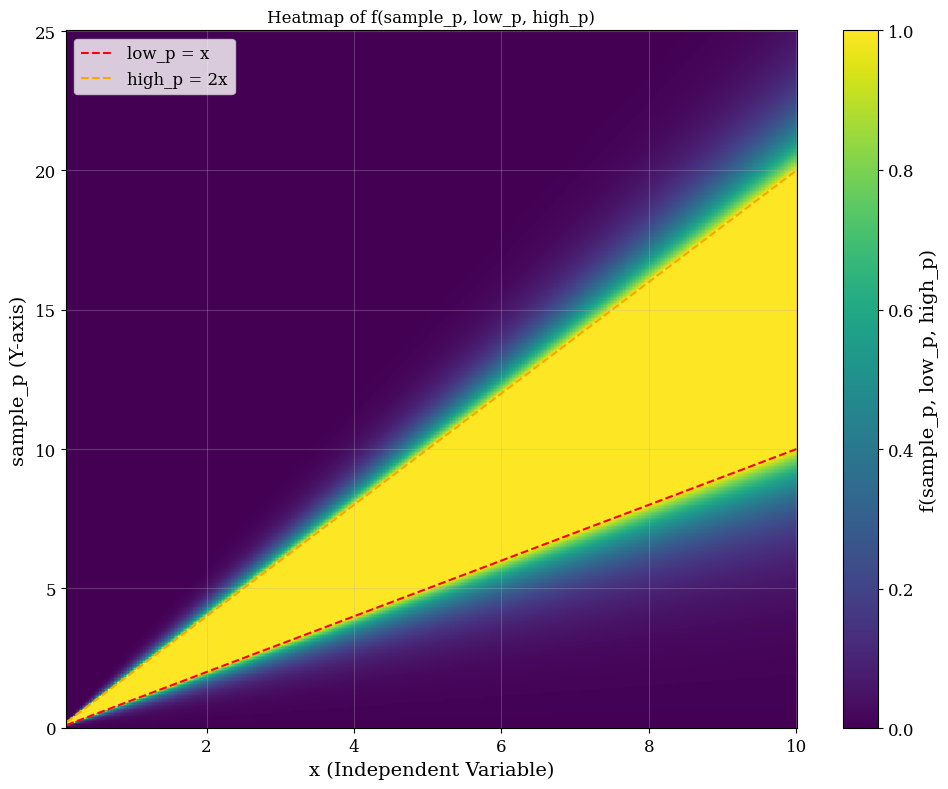

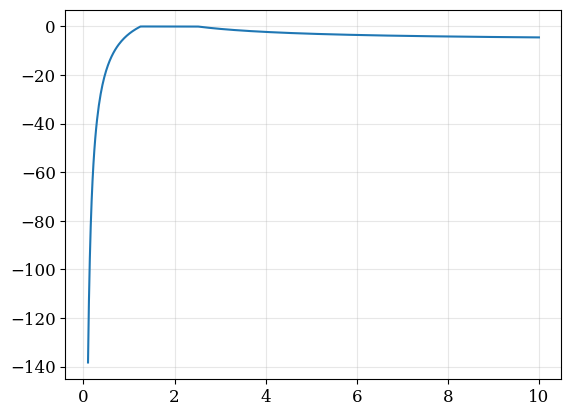

In [14]:
import jax.numpy as jnp
import jax.nn as nn
import matplotlib.pyplot as plt

# # Your exact function
# def f(sample_p, low_p, high_p):
#     beta = 6 / (high_p - low_p)
#     return_value = (
#         -beta * (sample_p - high_p) * jnp.heaviside(sample_p - high_p, 0)
#         + -beta * (low_p - sample_p) * jnp.heaviside(low_p - sample_p, 0)
#         + 1
#         * jnp.heaviside(sample_p - low_p, 0)
#         * jnp.heaviside(high_p - sample_p, 0)
#     )
#     return np.exp(return_value)

# def f(sample_p, low_p, high_p, beta_param=6.0):
#     # The denominator is calculated here. 
#     # beta_param is exposed as an argument, defaulting to your original 6.
#     beta_code = beta_param / (high_p - low_p)
    
#     return_value = (
#         -beta_code * (sample_p - high_p) * jnp.heaviside(sample_p - high_p, 0)
#         + -beta_code * (low_p - sample_p) * jnp.heaviside(low_p - sample_p, 0)
#         # The "+ 1" term is deleted. If neither condition above is met, 
#         # return_value is 0. jnp.exp(0) correctly returns 1.
#     )
    
#     # Changed np.exp to jnp.exp for JAX compatibility
#     return jnp.exp(return_value)
def f(sample_p, low_p, high_p):
    delta = jnp.maximum(high_p - low_p, 1e-7)
    beta = 6.0 / delta
    
    penalty_high = nn.relu(sample_p - high_p)
    penalty_low = nn.relu(low_p - sample_p)
    
    return jnp.exp(-beta * (penalty_high + penalty_low))
# 1. Define the grid for the independent variable x and sample_p (y-axis)
# Starting x at 0.1 to prevent division by zero in beta = 6 / (high_p - low_p)
x = jnp.linspace(0.1, 10.0, 500) 
sample_p_vals = jnp.linspace(0.0, 25.0, 500)

# 2. Create a 2D meshgrid
X, Y_sample_p = jnp.meshgrid(x, sample_p_vals)

# 3. Define the boundary functions based on the x-axis
low_p_vals = X        # y = x
high_p_vals = 2 * X   # y = 2x

# 4. Evaluate the function over the grid
Z = f(Y_sample_p, low_p_vals, high_p_vals)

# 5. Generate the heatmap
plt.figure(figsize=(10, 8))

# Using pcolormesh to map the X and Y coordinates to the Z values correctly
heatmap = plt.pcolormesh(X, Y_sample_p, Z, cmap='viridis', shading='auto')
plt.colorbar(heatmap, label='f(sample_p, low_p, high_p)')

# Overlay the linear functions for low_p and high_p for reference
plt.plot(x, x, color='red', linestyle='--', label='low_p = x')
plt.plot(x, 2 * x, color='orange', linestyle='--', label='high_p = 2x')

plt.xlabel('x (Independent Variable)')
plt.ylabel('sample_p (Y-axis)')
plt.title('Heatmap of f(sample_p, low_p, high_p)')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

plt.plot(X[50],jnp.log(Z[50]))
plt.show()